> Federated Learning workflow with Autonomous client and model aggregation methos selection

### 1. Import Libraries

In [1]:
from collections import deque, defaultdict
import copy
from dataclasses import dataclass, asdict, field
import logging
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from scipy import stats
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torchvision import datasets, transforms
from tqdm import tqdm
from typing import Dict, List, Optional, Tuple
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

training_harware = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using training_harware: {training_harware}")

/home/MacNight_nj/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using training_harware: cpu


### 2. Model building

In [2]:
class SimpleNet(nn.Module): # A simple CNN for image classification
   def __init__(self, in_channels: int = 1, num_classes: int = 10):

       """
       Building blocks of convolutional neural network.

       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. In our problem, 10 (i.e digits from  0 to 9).
       """
       super(SimpleNet, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x

In [ ]:
def local_train(
    model: SimpleNet,
    loader,
    epochs: int = 1,
    lr: float = 0.01,
) -> Tuple[float, Dict]:
    """Local training with gradient quality measurement"""
    model.train()
    # Define the loss function
    criterion = nn.CrossEntropyLoss()
    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    gradient_norms = []

    for _ in range(epochs):
        for batch_index, (data, targets) in enumerate(
            tqdm(loader, desc="Training", leave=False)
        ):
            data = data.to(training_harware)
            targets = targets.to(training_harware)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, targets)
            loss.backward()

            # Calculate gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1.0 / 2)
            gradient_norms.append(total_norm)

            optimizer.step()

    training_time = random.uniform(0.5, 2.0) * epochs  # Simulated training time
    gradient_quality = np.mean(gradient_norms) if gradient_norms else 0.0

    return training_time, model.state_dict(), gradient_quality


def evaluate(model, loader):
    # Set up of multiclass accuracy metric
    acc = Accuracy(task="multiclass", num_classes=10)

    # Iterate over the dataset batches
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            # Get predicted probabilities for test data batch
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            acc(preds, labels)

    # Compute total test accuracy
    test_accuracy = acc.compute()
    print(f"Test accuracy: {test_accuracy}")
    
    model.eval()
    correct = 0
    # For accuracy calculation
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
    accuracy = correct / len(loader.dataset)

    print(f"✅ Global model accuracy: {accuracy:.4f}")
    return accuracy

def compute_global_loss(model, val_loader, device):
    """
    Compute average CrossEntropy loss of `model` on `val_loader`.
    Returns float (mean loss across all samples).
    Safe: model.eval(), torch.no_grad(), handles batches and different sizes.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    loss_fn = torch.nn.CrossEntropyLoss(reduction='sum')  # sum -> we will divide by N

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            # ensure logits and labels shapes are correct:
            if logits.dim() == 1:
                logits = logits.unsqueeze(0)
            # compute batch sum loss
            batch_loss = loss_fn(logits, yb)
            bs = yb.size(0)
            total_loss += float(batch_loss.item())
            total_samples += bs

    if total_samples == 0:
        raise RuntimeError("Validation loader is empty (total_samples == 0).")
    mean_loss = total_loss / (total_samples + 1e-12)
    # sanity checks
    if np.isnan(mean_loss) or np.isinf(mean_loss):
        raise RuntimeError(f"Global loss is NaN/Inf: {mean_loss}")
    

    # optional debug print
    print(f"Round: global_loss = {float(mean_loss):.6f}")
    return float(mean_loss)


### 3. Dataset preparation

In [4]:
batch_size = 60

train_dataset = datasets.MNIST(root="data/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="data/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


#### 3.1. Data Distribution for Federated Learning

In [5]:
def create_non_iid_data_split(dataset, num_clients, alpha=0.3):
    """
    Create non-IID data splits using Dirichlet distribution
    
    Args:
        dataset: PyTorch dataset (MNIST)
        num_clients: Number of clients to split data among
        alpha: Dirichlet concentration parameter (lower = more heterogeneous)
    
    Returns:
        client_datasets: Dict mapping client_id to dataset indices
        client_stats: Dict with data distribution statistics
    """
    # Get labels
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    num_classes = len(np.unique(labels))
    
    # Group indices by class
    class_indices = {i: np.where(labels == i)[0] for i in range(num_classes)}
    
    # Generate Dirichlet distribution for each client
    client_datasets = {}
    client_stats = {}
    
    for index in range(num_clients):
        # Sample proportions from Dirichlet distribution
        proportions = np.random.dirichlet([alpha] * num_classes)
        
        # Calculate number of samples per class for this client
        client_indices = []
        class_counts = {}
        
        total_samples_per_client = len(dataset) // num_clients
        
        for class_idx in range(num_classes):
            n_samples = int(proportions[class_idx] * total_samples_per_client)
            if n_samples > 0 and len(class_indices[class_idx]) > 0:
                # Randomly sample from available indices for this class
                available_indices = class_indices[class_idx]
                selected_indices = np.random.choice(
                    available_indices, 
                    min(n_samples, len(available_indices)), 
                    replace=False
                )
                client_indices.extend(selected_indices)
                class_counts[class_idx] = len(selected_indices)
                
                # Remove selected indices from available pool
                # class_indices[class_idx] = np.setdiff1d(available_indices, selected_indices)
        
        client_datasets[f"client_{index}"] = client_indices
        client_stats[f"client_{index}"] = {
            'total_samples': len(client_indices),
            'class_distribution': class_counts,
            'heterogeneity_score': np.std(list(class_counts.values()))
        }
    
    return client_datasets, client_stats

def calculate_data_heterogeneity(client_stats):
    """Calculate overall data heterogeneity metrics"""
    all_distributions = []
    for stats_i in client_stats.values():
        dist = list(stats_i['class_distribution'].values())
        # Normalize to get proportions
        total = sum(dist)
        if total > 0:
            all_distributions.append([x/total for x in dist])
    
    if not all_distributions:
        return 0.0
    
    # Calculate Jensen-Shannon divergence as heterogeneity measure
    mean_dist = np.mean(all_distributions, axis=0)
    js_div = 0
    for dist in all_distributions:
        js_div += stats.entropy(dist, mean_dist)
    
    return js_div / len(all_distributions)


### 4. IoT devices/clients building

#### 4.1. Resource Information

In [6]:
# IoT Device and Gateway Communication Simulation
@dataclass
class BatteryState:
    design_capacity: float  # mAh
    current_capacity: float  # mAh (degrades over time)
    current_level: float  # percentage (0-100)
    voltage: float  # volts
    discharge_rate: float  # mA/h
    temperature: float  # Celsius
    cycle_count: int = 0  # number of charge/discharge cycles
    degradation_rate: float = 0.001  # capacity loss per cycle
    temperature_coefficient: float = -0.5  # %/°C performance impact
    age_days: int = 0
    last_charge_time: float = 0.0
    estimated_remaining: float = 0.0
    health_percentage: float = 100.0


@dataclass
class BandwidthState:
    max_uplink: float  # Mbps
    max_downlink: float  # Mbps
    current_uplink: float  # Mbps
    current_downlink: float  # Mbps
    packet_loss: float  # percentage
    base_latency: float  # milliseconds
    current_latency: float  # milliseconds
    jitter: float  # milliseconds
    signal_strength: float = -70.0  # dBm
    interference_level: float = 0.0  # 0-1 scale
    network_congestion: float = 0.0  # 0-1 scale
    connection_stability: float = 1.0  # 0-1 scale
    last_bandwidth_test: float = 0.0
    throughput_history: list = field(default_factory=list)


@dataclass
class MemoryState:
    total_ram: int  # KB
    used_ram: int  # KB
    free_ram: int  # KB
    buffer_usage: int  # KB
    cache_usage: int  # KB
    fragmentation_level: float = 0.0  # 0-1 scale
    memory_pressure: float = 0.0  # 0-1 scale
    gc_frequency: float = 1.0  # garbage collection frequency
    allocation_failures: int = 0
    peak_usage: int = 0
    memory_leaks: float = 0.0  # gradual memory loss
    compression_ratio: float = 1.0


@dataclass
class DeviceHealthMetrics:
    cpu_temperature: float = 25.0
    cpu_utilization: float = 0.0
    disk_usage: float = 0.0
    network_errors: int = 0
    system_uptime: float = 0.0
    failure_probability: float = 0.0
    maintenance_due: bool = False
    last_health_check: float = 0.0
    performance_score: float = 1.0


@dataclass
class Packet:
    source_id: str
    destination: str
    size: int  # bytes
    timestamp: float
    packet_type: str
    # priority: int          # 1-5 (5 = highest priority)
    retry_count: int  # number of retransmission attempts
    data: Optional[Dict] = None

#### 4.2. Resource Monitoring and Prediction

In [7]:
class BatteryDegradationModel:
    """Realistic battery degradation simulation"""
    
    @staticmethod
    def calculate_capacity_loss(battery: BatteryState, time_delta: float) -> float:
        """Calculate battery capacity loss over time"""
        # Calendar aging (time-based degradation)
        calendar_loss = 0.0001 * time_delta / 3600  # 0.01% per hour base rate
        
        # Temperature effect (Arrhenius equation approximation)
        temp_factor = math.exp((battery.temperature - 25) / 10)
        calendar_loss *= temp_factor
        
        # Cycle aging (usage-based degradation)
        cycle_loss = battery.cycle_count * battery.degradation_rate
        
        return min(calendar_loss + cycle_loss, 0.8)  # Max 80% degradation

    @staticmethod
    def update_battery_health(battery: BatteryState, time_delta: float, usage_intensity: float):
        """Update battery state over time"""
        # Calculate degradation
        capacity_loss = BatteryDegradationModel.calculate_capacity_loss(battery, time_delta)
        battery.current_capacity = battery.design_capacity * (1 - capacity_loss)
        battery.health_percentage = (battery.current_capacity / battery.design_capacity) * 100
        
        # Update discharge rate based on temperature
        temp_effect = 1 + (battery.temperature - 25) * battery.temperature_coefficient / 100
        battery.discharge_rate = battery.discharge_rate * temp_effect
        
        # Simulate usage cycles
        if usage_intensity > 0.5:  # High usage triggers cycle count
            battery.cycle_count += time_delta / 3600  # Approximate cycles per hour
        
        # Update estimated remaining time
        if battery.discharge_rate > 0:
            battery.estimated_remaining = (battery.current_level / 100) * battery.current_capacity / battery.discharge_rate            
            # Ensure battery level doesn't go negative or exceed capacity
            battery.current_level = max(0.0, min(100.0, battery.current_level))
            battery.current_capacity = max(0.0, battery.current_capacity)
            battery.estimated_remaining = max(0.0, battery.estimated_remaining)

class NetworkConditionModel:
    """Dynamic network condition simulation"""
    
    @staticmethod
    def simulate_network_fluctuation(bandwidth: BandwidthState, time_delta: float, location: Tuple[float, float]):
        """Simulate realistic network condition changes"""
        # Time-based interference patterns (e.g., daily patterns)
        time_of_day = (time.time() % 86400) / 86400  # 0-1 representing day progress
        daily_congestion = 0.3 + 0.4 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Location-based interference (simplified)
        location_factor = (hash(str(location)) % 100) / 100  # Deterministic but location-dependent
        
        # Random fluctuations
        random_factor = np.random.normal(1.0, 0.1)
        
        # Update network congestion
        bandwidth.network_congestion = np.clip(daily_congestion * location_factor * random_factor, 0, 1)
        
        # Update signal strength with interference
        base_signal = -70.0  # dBm
        interference_impact = bandwidth.interference_level * 20  # dB loss
        bandwidth.signal_strength = base_signal - interference_impact + np.random.normal(0, 5)
        
        # Update effective bandwidth
        congestion_factor = 1 - bandwidth.network_congestion * 0.7
        signal_factor = min(1.0, (bandwidth.signal_strength + 100) / 30)  # Signal quality factor
        
        bandwidth.current_uplink = bandwidth.max_uplink * congestion_factor * signal_factor
        bandwidth.current_downlink = bandwidth.max_downlink * congestion_factor * signal_factor
        
        # Update latency based on conditions
        base_latency_increase = bandwidth.network_congestion * 50  # ms
        signal_latency_increase = max(0, (-70 - bandwidth.signal_strength)) * 2  # ms per dB below -70
        bandwidth.current_latency = bandwidth.base_latency + base_latency_increase + signal_latency_increase
        
        # Update packet loss
        loss_from_congestion = bandwidth.network_congestion * 5  # Up to 5% from congestion
        loss_from_signal = max(0, (-80 - bandwidth.signal_strength)) * 0.5  # Loss from poor signal
        bandwidth.packet_loss = np.clip(loss_from_congestion + loss_from_signal, 0, 20)
        
        # Update connection stability
        stability_factors = [
            1 - bandwidth.network_congestion * 0.3,
            min(1.0, (bandwidth.signal_strength + 90) / 20),
            1 - bandwidth.interference_level * 0.4
        ]
        bandwidth.connection_stability = np.mean(stability_factors)

class MemoryManagementModel:
    """Advanced memory management simulation"""
    
    @staticmethod
    def simulate_memory_fragmentation(memory: MemoryState, time_delta: float, workload_intensity: float):
        """Simulate memory fragmentation over time"""
        # Fragmentation increases with usage and time
        fragmentation_increase = workload_intensity * time_delta * 0.001
        memory.fragmentation_level = min(1.0, memory.fragmentation_level + fragmentation_increase)
        
        # Memory pressure based on usage
        usage_ratio = memory.used_ram / memory.total_ram
        memory.memory_pressure = max(0, (usage_ratio - 0.7) / 0.3)  # Pressure starts at 70% usage
        
        # Garbage collection frequency adapts to pressure
        memory.gc_frequency = 1.0 + memory.memory_pressure * 2.0
        
        # Memory leaks (gradual loss of available memory)
        leak_rate = 0.1 * workload_intensity * time_delta / 3600  # KB per hour
        memory.memory_leaks = min(memory.total_ram * 0.1, memory.memory_leaks + leak_rate)
        
        # Update effective free memory
        effective_total = memory.total_ram - memory.memory_leaks
        fragmentation_overhead = memory.fragmentation_level * effective_total * 0.1
        memory.free_ram = max(0, effective_total - memory.used_ram - fragmentation_overhead)

class EnvironmentalModel:
    """Environmental condition simulation"""
    
    @staticmethod
    def simulate_temperature_variation(base_temp: float, time_delta: float, device_type: str) -> float:
        """Simulate realistic temperature changes"""
        # Daily temperature cycle
        time_of_day = (time.time() % 86400) / 86400
        daily_variation = 10 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Device type affects heat generation
        heat_generation = {
            'sensor': 2.0,
            'camera': 8.0,
            'actuator': 5.0,
            'tracker': 3.0,
            'gateway': 15.0
        }.get(device_type, 3.0)
        
        # Random fluctuations
        random_variation = np.random.normal(0, 2)
        
        return base_temp + daily_variation + heat_generation + random_variation


#### 4.3. IoT Device

In [8]:
class IoTDevice:
    def __init__(
        self,
        device_id: str,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Tuple[float, float] = (0.0, 0.0),
        local_model: SimpleNet = SimpleNet(),
        local_data_indices: List[int] = None,
    ):
        self.device_id = device_id
        self.device_type = device_type
        self.location = location  # (x, y) coordinates
        self.creation_time = time.time()
        self.local_data_indices = local_data_indices or []
        self.local_train_loader = None
        self.data_quality_score = 0.0
        self.participation_history = []
        self.rounds_since_participation = 0
        self.total_participation_count = 0
        self.gradient_quality_history = []
        self.reliability_score = 1.0
        self.energy_consumption_history = []

        # ML model for federated learning
        self.local_model = local_model

        # Real-world IoT device specifications
        device_specs = self._get_device_specifications(device_type)

        self.battery = BatteryState(
            design_capacity=device_specs["battery_capacity"],
            current_level=initial_battery,
            current_capacity=device_specs["battery_capacity"],
            voltage=device_specs["battery_voltage"],
            discharge_rate=device_specs["discharge_rate"],
            temperature=random.uniform(20.0, 35.0),
        )

        self.bandwidth = BandwidthState(
            max_uplink=device_specs["max_uplink"],
            max_downlink=device_specs["max_downlink"],
            current_uplink=device_specs["max_uplink"],
            current_downlink=device_specs["max_downlink"],
            packet_loss=0.0,
            base_latency=random.uniform(10, 50),
            current_latency=random.uniform(10, 50),
            jitter=random.uniform(1, 5),
        )

        self.memory = MemoryState(
            total_ram=device_specs["total_ram"],
            used_ram=0,
            free_ram=device_specs["total_ram"],
            buffer_usage=0,
            cache_usage=0,
        )

        self.is_active = True
        self.packet_queue = deque(maxlen=device_specs["queue_limit"])
        self.last_transmission = time.time()
        self.network_condition = "GOOD"  # Current network state
        self.energy_harvesting = device_specs.get("energy_harvesting", False)
        self.sleep_mode = False
        self.health_metrics = DeviceHealthMetrics()
        self.last_state_update = time.time()
        self.workload_history = deque(maxlen=50)
        self.performance_trend = deque(maxlen=20)

        # Update initial memory state
        self.stats = {
            "packets_sent": 0,
            "packets_failed": 0,
            "total_data_sent": 0,
            "avg_power_consumption": 0.0,
            "connection_uptime": 0.0,
        }

        # self._update_memory_state()
        logger.info(
            f"Device {device_id} ({device_type}) initialized at {location} with {self.battery.design_capacity}mAh battery"
        )

    def simulate_time_passage(self, time_delta: float):
        """Simulate the passage of time and update all device states"""
        current_time = time.time()

        # Calculate workload intensity from recent activity
        workload_intensity = len(self.packet_queue) / (self.packet_queue.maxlen or 1)
        self.workload_history.append(workload_intensity)

        # Update battery state
        BatteryDegradationModel.update_battery_health(
            self.battery, time_delta, workload_intensity
        )

        # Update battery level based on usage
        energy_consumed = (
            self.battery.discharge_rate * time_delta / 3600
        )  # mAh consumed
        if self.battery.current_capacity > 0:
            level_decrease = (energy_consumed / self.battery.current_capacity) * 100
            self.battery.current_level = max(
                0, self.battery.current_level - level_decrease
            )

        # Update network conditions
        NetworkConditionModel.simulate_network_fluctuation(
            self.bandwidth, time_delta, self.location
        )

        # Update memory state
        MemoryManagementModel.simulate_memory_fragmentation(
            self.memory, time_delta, workload_intensity
        )

        # Update environmental conditions
        self.battery.temperature = EnvironmentalModel.simulate_temperature_variation(
            self.battery.temperature, time_delta, self.device_type
        )

        # Update health metrics
        self._update_health_metrics(workload_intensity)

        # Record performance trend
        performance_score = self._calculate_performance_score()
        self.performance_trend.append(performance_score)

        self.last_state_update = current_time

    def _update_health_metrics(self, workload_intensity: float):
        """Update device health metrics"""
        # CPU utilization correlates with workload
        self.health_metrics.cpu_utilization = min(
            1.0, workload_intensity + np.random.normal(0, 0.1)
        )

        # CPU temperature affected by utilization
        temp_increase = self.health_metrics.cpu_utilization * 20
        self.health_metrics.cpu_temperature = self.battery.temperature + temp_increase

        # System uptime
        self.health_metrics.system_uptime = time.time() - self.creation_time

        # Failure probability based on multiple factors
        age_factor = min(
            1.0, self.health_metrics.system_uptime / (365 * 24 * 3600)
        )  # Age in years
        battery_factor = 1 - (self.battery.health_percentage / 100)
        temp_factor = max(
            0, (self.health_metrics.cpu_temperature - 60) / 40
        )  # Risk above 60°C

        self.health_metrics.failure_probability = np.clip(
            age_factor * 0.1 + battery_factor * 0.3 + temp_factor * 0.4, 0, 1
        )

        # Performance score (0-1)
        self.health_metrics.performance_score = 1.0 - (
            battery_factor * 0.3
            + self.memory.fragmentation_level * 0.2
            + (1 - self.bandwidth.connection_stability) * 0.3
            + temp_factor * 0.2
        )

    def _calculate_performance_score(self) -> float:
        """Calculate overall device performance score"""
        battery_score = self.battery.current_level / 100.0
        memory_score = self.memory.free_ram / self.memory.total_ram
        network_score = self.bandwidth.connection_stability
        health_score = self.health_metrics.performance_score

        return np.mean([battery_score, memory_score, network_score, health_score])

    def predict_remaining_lifetime(self) -> float:
        """Predict remaining operational lifetime in hours"""
        if self.battery.current_level <= 0:
            return 0.0

        # Current battery life
        battery_hours = self.battery.estimated_remaining

        # Factor in degradation trend
        if len(self.performance_trend) > 5:
            trend_slope = np.polyfit(
                range(len(self.performance_trend)), list(self.performance_trend), 1
            )[0]
            # Adjust lifetime based on performance trend
            trend_factor = max(0.5, 1 + trend_slope * 10)
            battery_hours *= trend_factor

        # Factor in failure probability
        reliability_factor = 1 - self.health_metrics.failure_probability

        return battery_hours * reliability_factor

    def assign_local_data(self, dataset, indices):
        """Assign local dataset to device"""
        self.local_data_indices = indices
        subset = Subset(dataset, indices)
        self.local_train_loader = DataLoader(subset, shuffle=True)

        # Calculate data quality metrics
        labels = [dataset[i][1] for i in indices]
        unique_labels, counts = np.unique(labels, return_counts=True)
        self.data_quality_score = (
            len(unique_labels) / 10.0
        )  # Normalize by total classes

        logger.info(
            f"Device {self.device_id} assigned {len(indices)} samples with {len(unique_labels)} classes"
        )

    def update_participation_metrics(
        self, participated: bool, gradient_quality: float = 0.0
    ):
        """Update participation and performance metrics"""
        self.participation_history.append(participated)
        if participated:
            self.rounds_since_participation = 0
            self.total_participation_count += 1
            if gradient_quality > 0:
                self.gradient_quality_history.append(gradient_quality)
        else:
            self.rounds_since_participation += 1

        # Keep only last 50 rounds of history
        if len(self.participation_history) > 50:
            self.participation_history = self.participation_history[-50:]

    def _get_device_specifications(self, device_type: str) -> Dict:
        """Get realistic specifications for different IoT device types"""
        specs = {
            "sensor": {
                "total_ram": random.randint(8, 64),
                "battery_voltage": 3.3,
                "battery_capacity": random.uniform(500, 2000),
                "discharge_rate": random.uniform(0.5, 5.0),  # mAh/h
                "max_uplink": 0.025,  # LoRaWAN typical
                "max_downlink": 0.025,
                "queue_limit": 10,
                "energy_harvesting": random.choice(
                    [True, False]
                ),  # Some sensors have solar panels
            },
            "actuator": {
                "total_ram": random.randint(16, 128),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(1000, 3000),
                "discharge_rate": random.uniform(5.0, 20.0),
                "max_uplink": 0.1,
                "max_downlink": 0.2,
                "queue_limit": 20,
                "energy_harvesting": False,
            },
            "camera": {
                "total_ram": random.randint(512, 2048),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(3000, 8000),
                "discharge_rate": random.uniform(50.0, 200.0),
                "max_uplink": 2.0,
                "max_downlink": 0.5,
                "queue_limit": 50,
                "energy_harvesting": False,
            },
            "gateway": {
                "total_ram": random.randint(1024, 8192),
                "battery_voltage": 5.0,
                "battery_capacity": random.uniform(10000, 20000),
                "discharge_rate": random.uniform(100.0, 500.0),
                "max_uplink": 10.0,
                "max_downlink": 10.0,
                "queue_limit": 100,
                "energy_harvesting": False,
            },
            "tracker": {
                "total_ram": random.randint(32, 256),
                "battery_voltage": 3.6,
                "battery_capacity": random.uniform(800, 2500),
                "discharge_rate": random.uniform(2.0, 15.0),
                "max_uplink": 0.05,
                "max_downlink": 0.05,
                "queue_limit": 15,
                "energy_harvesting": random.choice([True, False]),
            },
        }
        return specs.get(device_type, specs["sensor"])

    def can_participate(self) -> bool:
        """Check if device can participate in training"""
        # Basic resource checks
        battery_ok = self.battery.current_level > 15  # Increased threshold
        memory_ok = (self.memory.free_ram / self.memory.total_ram) > 0.2
        network_ok = self.bandwidth.connection_stability > 0.6
        health_ok = self.health_metrics.failure_probability < 0.7

        # Predictive checks
        lifetime_ok = (
            self.predict_remaining_lifetime() > 1.0
        )  # At least 2 hours remaining
        performance_ok = self._calculate_performance_score() > 0.3

        return all(
            [battery_ok, memory_ok, network_ok, health_ok, lifetime_ok, performance_ok]
        )

    def train_model_and_generate_packet(
        self,
        destination: str,
        epochs: int,
        global_update: dict[str, any],
    ) -> Packet:
        """Enhanced packet generation with priority and adaptive sizing"""

        if not self.local_train_loader:
            logger.warning(f"Device {self.device_id} has no local data assigned")
            return None

        packet_types = ["global_model", "local_update"]

        # Load global updated model if available
        self.local_model.load_state_dict(global_update)

        # Local model training
        training_time, local_update, gradient_quality = local_train(
            model=self.local_model,
            loader=train_loader,
            epochs=epochs,
        )
        packet_size = len(local_update) / (1024 * 1024)  # MB

        packet = Packet(
            source_id=self.device_id,
            destination=destination,
            size=packet_size,
            timestamp=time.time(),
            packet_type=packet_types[1],
            retry_count=0,
            data={
                "local_update": local_update,
                "training_time": training_time,
                "gradient_quality": gradient_quality,
                "data_samples": len(self.local_data_indices),
            },
        )

        if len(self.packet_queue) < self.packet_queue.maxlen:
            self.packet_queue.append(packet)
        else:
            logger.warning(f"Packet queue full for device {self.device_id}")

        return packet

    def transmit_packet(self) -> Optional[Tuple[bool, Packet]]:
        """Simulate packet transmission with resource updates"""
        if not self.packet_queue or self.battery.current_level < 5:
            return None

        # Enter sleep mode if battery is very low
        if self.battery.current_level < 10:
            self.sleep_mode = True
        else:
            self.sleep_mode = False

        packet = self.packet_queue.popleft()

        # Calculate transmission success probability
        success_probability = 0.95  # Base success rate
        if self.network_condition == "BAD":
            success_probability = 0.7
        if self.bandwidth.packet_loss > 10:
            success_probability *= 0.8

        # Simulate transmission attempt
        if random.random() > success_probability:
            packet.retry_count += 1
            if packet.retry_count < 3:  # Allow up to 3 retries
                self.packet_queue.appendleft(packet)  # Put back at front of queue
                self.stats["packets_failed"] += 1
                return None

        self.last_transmission = time.time()
        self.stats["packets_sent"] += 1
        self.stats["total_data_sent"] += packet.size

        return (True, packet)

    def get_status(self) -> Dict:
        """Get current device status"""
        uptime = time.time() - self.creation_time
        self.stats["connection_uptime"] = uptime

        return {
            "device_id": self.device_id,
            "device_type": self.device_type,
            "location": self.location,
            "is_active": self.is_active and self.battery.current_level > 0,
            "sleep_mode": self.sleep_mode,
            "battery": asdict(self.battery),
            "bandwidth": asdict(self.bandwidth),
            "memory": asdict(self.memory),
            "queue_size": len(self.packet_queue),
            "last_transmission": self.last_transmission,
            "network_condition": self.network_condition,
            "energy_harvesting": self.energy_harvesting,
            "stats": self.stats.copy(),
            "uptime_hours": uptime / 3600,
        }

### 5. Autonomic Computing building

#### 5.3. Temporal State Evolution and Monitoring

In [9]:
class NetworkHealthMonitor:
    """System-wide network health monitoring"""
    
    def __init__(self):
        self.device_health_history = defaultdict(list)
        self.network_events = []
        self.alert_thresholds = {
            'battery_critical': 10,
            'failure_probability_high': 0.8,
            'network_degraded': 0.3,
            'memory_pressure_high': 0.8
        }
    
    def collect_device_telemetry(self, devices: List[IoTDevice]):
        """Collect telemetry from all devices"""
        current_time = time.time()
        
        for device in devices:
            health_data = {
                'timestamp': current_time,
                'device_id': device.device_id,
                'battery_level': device.battery.current_level,
                'battery_health': device.battery.health_percentage,
                'network_stability': device.bandwidth.connection_stability,
                'memory_pressure': device.memory.memory_pressure,
                'failure_probability': device.health_metrics.failure_probability,
                'performance_score': device._calculate_performance_score(),
                'predicted_lifetime': device.predict_remaining_lifetime()
            }
            
            self.device_health_history[device.device_id].append(health_data)
            
            # Keep only last 1000 records per device
            if len(self.device_health_history[device.device_id]) > 1000:
                self.device_health_history[device.device_id] = \
                    self.device_health_history[device.device_id][-1000:]
            
            # Check for alerts
            self._check_device_alerts(health_data)
    
    def _check_device_alerts(self, health_data: Dict):
        """Check for alert conditions"""
        alerts = []
        
        if health_data['battery_level'] < self.alert_thresholds['battery_critical']:
            alerts.append(f"CRITICAL: Device {health_data['device_id']} battery at {health_data['battery_level']:.1f}%")
        
        if health_data['failure_probability'] > self.alert_thresholds['failure_probability_high']:
            alerts.append(f"WARNING: Device {health_data['device_id']} high failure risk: {health_data['failure_probability']:.2f}")
        
        if health_data['network_stability'] < self.alert_thresholds['network_degraded']:
            alerts.append(f"NETWORK: Device {health_data['device_id']} poor connectivity: {health_data['network_stability']:.2f}")
        
        for alert in alerts:
            self.network_events.append({
                'timestamp': health_data['timestamp'],
                'type': 'ALERT',
                'message': alert
            })
    
    def get_network_health_summary(self, devices: List[IoTDevice]) -> Dict:
        """Get overall network health summary"""
        if not devices:
            return {}
        
        # Collect current metrics
        battery_levels = [d.battery.current_level for d in devices]
        performance_scores = [d._calculate_performance_score() for d in devices]
        failure_probs = [d.health_metrics.failure_probability for d in devices]
        network_stabilities = [d.bandwidth.connection_stability for d in devices]
        
        summary = {
            'total_devices': len(devices),
            'active_devices': len([d for d in devices if d.is_active]),
            'avg_battery_level': np.mean(battery_levels),
            'min_battery_level': np.min(battery_levels),
            'avg_performance_score': np.mean(performance_scores),
            'high_risk_devices': len([p for p in failure_probs if p > 0.7]),
            'network_stability': np.mean(network_stabilities),
            'devices_needing_attention': len([d for d in devices if 
                d.battery.current_level < 20 or 
                d.health_metrics.failure_probability > 0.6 or
                d.bandwidth.connection_stability < 0.4])
        }
        
        return summary

class NetworkDepletionTracker:
    """Track network energy depletion rate over time"""
    
    def __init__(self):
        self.initial_total_energy = 0
        self.energy_history = []  # Total network energy each round
        self.depletion_rate_history = []  # Energy consumption rate each round
        self.cumulative_depletion = []  # Cumulative energy consumed
        self.participation_energy_cost = []  # Energy cost per participation
    
    def get_survival_rate(self, devices: List[IoTDevice]) -> float:
        """Calculate current network survival rate"""
        if not devices:
            return 0.0
        
        active_count = sum(1 for d in devices if d.is_active and d.battery.current_level > 5)
        return active_count / len(devices)

    def record_round_energy(self, devices: List[IoTDevice], selected_devices: List[IoTDevice], round_num: int):
        """Record energy state for this round"""
        # Calculate current total network energy
        current_total_energy = 0
        active_devices = 0
        
        for device in devices:
            if device.is_active:
                device_energy = (device.battery.current_level / 100.0) * device.battery.current_capacity
                current_total_energy += device_energy
                active_devices += 1
        
        # Store initial energy on first round
        if round_num == 0:
            self.initial_total_energy = current_total_energy
            self.energy_history.append(current_total_energy)
            self.depletion_rate_history.append(0.0)
            self.cumulative_depletion.append(0.0)
            self.participation_energy_cost.append(0.0)
            return
        
        # Calculate energy consumed this round
        previous_energy = self.energy_history[-1]
        energy_consumed = previous_energy - current_total_energy
        
        # Calculate depletion rate (energy consumed per round)
        depletion_rate = energy_consumed / max(1, len(selected_devices))  # Per participating device
        
        # Update tracking
        self.energy_history.append(current_total_energy)
        self.depletion_rate_history.append(energy_consumed)  # Absolute consumption
        
        # Cumulative depletion percentage
        total_consumed = self.initial_total_energy - current_total_energy
        cumulative_percentage = (total_consumed / self.initial_total_energy) * 100 if self.initial_total_energy > 0 else 0
        self.cumulative_depletion.append(cumulative_percentage)
        
        # Energy cost per participation
        self.participation_energy_cost.append(depletion_rate)
    
    def get_network_depletion_stats(self) -> Dict:
        """Get comprehensive depletion statistics"""
        if len(self.energy_history) < 2:
            return {}
        
        # Calculate depletion acceleration (change in depletion rate)
        depletion_acceleration = []
        for i in range(1, len(self.depletion_rate_history)):
            acceleration = self.depletion_rate_history[i] - self.depletion_rate_history[i-1]
            depletion_acceleration.append(acceleration)
        
        return {
            'initial_energy': self.initial_total_energy,
            'current_energy': self.energy_history[-1],
            'total_consumed': self.initial_total_energy - self.energy_history[-1],
            'depletion_percentage': self.cumulative_depletion[-1],
            'avg_depletion_rate': np.mean(self.depletion_rate_history[1:]) if len(self.depletion_rate_history) > 1 else 0,
            'current_depletion_rate': self.depletion_rate_history[-1],
            'avg_participation_cost': np.mean(self.participation_energy_cost[1:]) if len(self.participation_energy_cost) > 1 else 0,
            'depletion_acceleration': np.mean(depletion_acceleration) if depletion_acceleration else 0
        }

class DeviceFailureSimulator:
    """Simulate realistic device failures and recovery"""
    
    @staticmethod
    def simulate_random_failures(devices: List[IoTDevice], failure_rate: float = 0.001):
        """Simulate random device failures"""
        failed_devices = []
        
        for device in devices:
            # Failure probability increases with device health issues
            base_failure_prob = failure_rate
            health_multiplier = 1 + device.health_metrics.failure_probability * 10
            effective_failure_prob = min(0.1, base_failure_prob * health_multiplier)
            
            if random.random() < effective_failure_prob:
                device.is_active = False
                device.battery.current_level = 0
                failed_devices.append(device.device_id)
                logger.warning(f"Device {device.device_id} failed due to hardware issues")
        
        return failed_devices
    
    @staticmethod
    def simulate_recovery(devices: List[IoTDevice], recovery_rate: float = 0.01):
        """Simulate device recovery (repair/replacement)"""
        recovered_devices = []
        
        for device in devices:
            if not device.is_active and random.random() < recovery_rate:
                # Reset device to operational state
                device.is_active = True
                device.battery.current_level = random.uniform(70, 100)
                device.battery.health_percentage = random.uniform(80, 100)
                device.health_metrics.failure_probability = 0.0
                recovered_devices.append(device.device_id)
                logger.info(f"Device {device.device_id} recovered and back online")
        
        return recovered_devices

class NetworkLifetimeTracker:
    """Track network lifetime and critical events"""
    
    def __init__(self):
        self.lifetime_history = []
        self.critical_events = []
        self.initial_total_energy = 0
        self.energy_consumption_rate = []
        
    def record_round_state(self, devices: List[IoTDevice], round_num: int):
        """Record network state for this round"""
        current_time = time.time()
        
        # Calculate total remaining energy
        total_energy = 0
        active_devices = 0
        
        for device in devices:
            if device.is_active:
                device_energy = (device.battery.current_level / 100.0) * device.battery.current_capacity
                total_energy += device_energy
                active_devices += 1
        
        # Store initial energy on first round
        if round_num == 0:
            self.initial_total_energy = total_energy
        
        # Calculate predicted network lifetime in hours
        if len(self.lifetime_history) > 0:
            energy_consumed = self.lifetime_history[-1] - total_energy
            self.energy_consumption_rate.append(energy_consumed)
            
            # Average consumption rate over last 5 rounds
            recent_rate = np.mean(self.energy_consumption_rate[-5:]) if self.energy_consumption_rate else 1
            predicted_lifetime = total_energy / max(0.1, recent_rate) if recent_rate > 0 else 100
        else:
            predicted_lifetime = 100  # Default for first round
        
        self.lifetime_history.append(predicted_lifetime)
        
        # Check for critical events
        if predicted_lifetime < 10:  # Less than 10 hours remaining
            self.critical_events.append({
                'round': round_num,
                'type': 'LOW_LIFETIME',
                'value': predicted_lifetime,
                'timestamp': current_time
            })
        
        if active_devices < len(devices) * 0.5:  # Less than 50% devices active
            self.critical_events.append({
                'round': round_num,
                'type': 'LOW_PARTICIPATION',
                'value': active_devices / len(devices),
                'timestamp': current_time
            })
    
    def get_survival_rate(self, devices: List[IoTDevice]) -> float:
        """Calculate current network survival rate"""
        if not devices:
            return 0.0
        
        active_count = sum(1 for d in devices if d.is_active and d.battery.current_level > 5)
        return active_count / len(devices)

#### 5.4. Multi-objectives optimization

##### 5.4.1. Objective Function

In [10]:
class ObjectiveFunction:
    """Multi-objective function definitions following thesis specifications exactly"""

    def __init__(self):
        self.history = {
            "depletion_rate": [],
            "convergence_speed": [],
            "fairness": [],
            "energy_efficiency": [],
            "composite_score": [],
        }
        # Tracking for min-max normalization
        self.round_min_max = {}

    @staticmethod
    def calculate_energy_costs(device: IoTDevice) -> Tuple[float, float]:
        """Calculate E_train and E_trans following Equation 3.8"""
        # Training cost parameters
        kappa_i = 1e-9  # Effective capacitance coefficient
        zeta_i = 10  # CPU cycles per sample
        I_i = 1  # Local iterations
        D_i = len(device.local_data_indices) if device.local_data_indices else 1
        f_i = 1000  # CPU frequency (MHz)

        # E_train = κ_i * I_i * ζ_i * |D_i| * f_i^2
        E_train_i = kappa_i * I_i * zeta_i * D_i * (f_i**2)

        # Transmission cost parameters
        rho_i = device.bandwidth.current_uplink / 100.0  # Normalized transmission power
        W_i = 1000  # Model size in bits (simplified)
        beta_i = 0.5  # Resource allocation ratio
        B = device.bandwidth.max_uplink
        H_i = 1.0  # Channel vector magnitude (simplified)
        N_0 = 1e-10  # Noise power spectral density

        # E_trans = ρ_i^2 * (W_i / (β_i * B * log(1 + ||ρ_i*H_i||^2/(β_i*B*N_0))))
        if B > 0:
            channel_gain = (rho_i * H_i) ** 2
            noise_term = beta_i * B * N_0
            if channel_gain / noise_term > 0:
                log_term = math.log(1 + channel_gain / noise_term)
                E_trans_i = (rho_i**2) * (W_i / (beta_i * B * log_term))
            else:
                E_trans_i = (rho_i**2) * W_i  # Fallback
        else:
            E_trans_i = (rho_i**2) * W_i

        return E_train_i, E_trans_i

    def depletion_rate_raw(
        self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]
    ) -> float:
        """Raw depletion rate Φ(C') following Equation 3.7"""
        if not selected_devices:
            return 0.0

        depletion_sum = 0.0
        for device in selected_devices:
            E_train_i, E_trans_i = self.calculate_energy_costs(device)
            E_cost_i = E_train_i + E_trans_i

            # Current total energy of device i
            E_total_i = (
                device.battery.current_level / 100.0
            ) * device.battery.current_capacity

            if E_total_i > 0:
                # Model size weight W_i
                W_i = 1000  # bits
                depletion_sum += (E_cost_i / E_total_i) * W_i

        return depletion_sum

    def convergence_speed_raw(self, selected_devices: List[IoTDevice]) -> float:
        """Raw convergence speed Γ(C') following Equation 3.9"""
        if not selected_devices:
            return 0.0

        alpha = 0.6  # Weight for data quality
        gamma = 0.4  # Weight for loss history
        convergence_sum = 0.0

        for device in selected_devices:
            # Data quality d_i
            d_i = (
                device.data_quality_score
                if hasattr(device, "data_quality_score")
                else 0.5
            )

            # Loss quality L_i(w_{t-1}) - use gradient quality as proxy
            if device.gradient_quality_history:
                recent_gradients = device.gradient_quality_history[-3:]
                L_i = np.mean(recent_gradients)
            else:
                L_i = 0.1

            convergence_sum += alpha * d_i + gamma * L_i

        return convergence_sum / len(selected_devices)

    def fairness_raw(
        self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]
    ) -> float:
        """Raw fairness Ω(C') using Jain's Index following Equation 3.10"""
        if not selected_devices:
            return 1.0

        # Get selection counts s_i for selected devices only
        selection_counts = [d.total_participation_count for d in selected_devices]

        if all(count == 0 for count in selection_counts):
            return 1.0

        # Jain's Fairness Index: (Σs_i)^2 / (|C'| * Σs_i^2)
        sum_s = sum(selection_counts)
        sum_s_squared = sum(s**2 for s in selection_counts)
        n = len(selected_devices)

        if sum_s_squared == 0 or sum_s == 0:
            return 1.0

        jains_index = (sum_s**2) / (n * sum_s_squared)
        return jains_index

    def energy_efficiency_raw(self, selected_devices: List[IoTDevice]) -> float:
        """Raw energy efficiency Θ(C') following Equation 3.11"""
        if not selected_devices:
            return 0.0

        theta_sum = 0.0
        EPS = 1e-9
        for device in selected_devices:
            E_train_i, E_trans_i = self.calculate_energy_costs(device)
            E_cost_i = E_train_i + E_trans_i

            # Current total energy
            E_total_i = (
                device.battery.current_level / 100.0
            ) * device.battery.current_capacity

            # Residual energy E_rem_i = E_total_i - E_cost_i
            E_rem_i = E_total_i - E_cost_i

            if E_cost_i > 0 and E_rem_i > 0:
                # Θ_i = E_rem_i / E_cost_i (should be > 1)
                theta_i = E_rem_i / (E_cost_i + EPS)
                theta_sum += theta_i
            else:
                theta_sum += 0.0

        return theta_sum

    def calculate_all_objectives_with_normalization(
        self, all_devices: List[IoTDevice], candidate_sets: List[List[IoTDevice]]
    ) -> List[Dict[str, float]]:
        """Calculate normalized objectives for all candidate sets following thesis methodology"""
        if not candidate_sets:
            return []

        # Step 1: Calculate raw values for all candidates
        raw_values = []
        for candidate_set in candidate_sets:
            raw_vals = {
                "depletion": self.depletion_rate_raw(all_devices, candidate_set),
                "convergence": self.convergence_speed_raw(candidate_set),
                "fairness": self.fairness_raw(all_devices, candidate_set),
                "energy_efficiency": self.energy_efficiency_raw(candidate_set),
            }
            raw_values.append(raw_vals)

        # Step 2: Find min/max for normalization (round-local)
        if len(raw_values) > 1:
            depletion_values = [rv["depletion"] for rv in raw_values]
            convergence_values = [rv["convergence"] for rv in raw_values]
            energy_values = [rv["energy_efficiency"] for rv in raw_values]

            phi_min, phi_max = min(depletion_values), max(depletion_values)
            gamma_min, gamma_max = min(convergence_values), max(convergence_values)
            theta_min, theta_max = min(energy_values), max(energy_values)
        else:
            # Single candidate - no normalization needed
            phi_min = phi_max = raw_values[0]["depletion"]
            gamma_min = gamma_max = raw_values[0]["convergence"]
            theta_min = theta_max = raw_values[0]["energy_efficiency"]

        # Step 3: Normalize and convert to reward form
        normalized_objectives = []
        for raw_vals in raw_values:
            # Depletion reward (minimize → maximize): R_Φ = 1 - (Φ - Φ_min)/(Φ_max - Φ_min)
            if phi_max == phi_min:
                R_phi_hat = 0.5
            else:
                R_phi_hat = 1.0 - (raw_vals["depletion"] - phi_min) / (
                    phi_max - phi_min
                )

            # Convergence (maximize): Γ_hat = (Γ - Γ_min)/(Γ_max - Γ_min)
            if gamma_max == gamma_min:
                gamma_hat = 1.0 if raw_vals["convergence"] > 0 else 0.0
            else:
                gamma_hat = (raw_vals["convergence"] - gamma_min) / (
                    gamma_max - gamma_min
                )

            # Fairness (already in [0,1]): Ω_hat = Ω
            omega_hat = raw_vals["fairness"]

            # Energy efficiency (maximize): Θ_hat = (Θ - Θ_min)/(Θ_max - Θ_min)
            if theta_max == theta_min:
                theta_hat = 1.0 if raw_vals["energy_efficiency"] > 0 else 0.0
            else:
                theta_hat = (raw_vals["energy_efficiency"] - theta_min) / (
                    theta_max - theta_min
                )

            normalized_objectives.append(
                {
                    "depletion_rate": max(0.0, min(1.0, R_phi_hat)),
                    "convergence_speed": max(0.0, min(1.0, gamma_hat)),
                    "fairness": max(0.0, min(1.0, omega_hat)),
                    "energy_efficiency": max(0.0, min(1.0, theta_hat)),
                }
            )

        return normalized_objectives

    def calculate_composite_score(
        self, objectives: Dict[str, float], weights: Dict[str, float]
    ) -> float:
        """Calculate composite score: Score(C') = ϑR̂_Φ + χΓ̂ + λΩ̂ + τΘ̂"""
        assert abs(sum(weights.values()) - 1.0) < 1e-6, "weights must sum to 1"
        composite_score = (
            weights.get("depletion_rate", 0.25) * objectives.get("depletion_rate", 0.0)
            + weights.get("convergence_speed", 0.30)
            * objectives.get("convergence_speed", 0.0)
            + weights.get("fairness", 0.20) * objectives.get("fairness", 0.0)
            + weights.get("energy_efficiency", 0.25)
            * objectives.get("energy_efficiency", 0.0)
        )

        return composite_score

In [11]:
class ObjectiveWeightManager:
    """Adaptive weight management using deficit-driven softmax + EMA from thesis documents"""
    
    def __init__(self):
        # Initial weights (ϑ, χ, λ, τ)
        self.weights = {
            'depletion_rate': 0.25,      # ϑ (vartheta)
            'convergence_speed': 0.30,   # χ (chi)
            'fairness': 0.20,            # λ (lambda)  
            'energy_efficiency': 0.25    # τ (tau)
        }
        
        # Hyperparameters from thesis
        self.eta = 5.0          # Softmax sensitivity
        self.beta = 0.2         # EMA smoothing factor
        self.w_min = 0.05       # Minimum weight
        self.w_max = 0.7        # Maximum weight
        self.normalizer = 0.2   # Deficit normalizer
        
        # Target values
        self.targets = {
            'J_star': 0.9,          # Target Jain's index
            'Phi_star': 0.05,       # Target depletion rate
            'E_star': 0.5,          # Target residual energy fraction
            'epsilon_loss': 0.002   # Target loss improvement per round
        }
        
        # History tracking
        self.weight_history = []
        self.deficit_history = []
        self.validation_loss_history = []
        self.previous_loss = None
        
    def calculate_global_signals(self, devices: List[IoTDevice], selected_devices: List[IoTDevice], 
                                current_loss: float, round_num: int) -> Dict[str, float]:
        """Calculate global signals for adaptive weight adjustment"""
        
        # 1. Convergence signal: ΔL_t = L_val_{t-1} - L_val_t
        if self.previous_loss is not None:
            delta_L = self.previous_loss - current_loss
        else:
            delta_L = 0.0
        
        self.previous_loss = current_loss
        self.validation_loss_history.append(current_loss)
        
        # 2. Fairness signal: Jain index
        active_devices = [d for d in devices if d.is_active]
        if len(active_devices) > 1:
            selection_counts = [d.total_participation_count for d in active_devices]
            if any(count > 0 for count in selection_counts):
                sum_s = sum(selection_counts)
                sum_s_squared = sum(s**2 for s in selection_counts)
                n = len(active_devices)
                J_t = (sum_s ** 2) / (n * sum_s_squared)
            else:
                J_t = 1.0
        else:
            J_t = 1.0
        
        # 3. Depletion signal: Average depletion among selected devices
        if selected_devices:
            total_depletion = 0.0
            for device in selected_devices:
                E_total = (device.battery.current_level / 100.0) * device.battery.current_capacity
                if E_total > 0:
                    # Simplified depletion rate
                    depletion_rate = device.battery.discharge_rate / E_total
                    total_depletion += depletion_rate
            Phi_avg = total_depletion / len(selected_devices)
        else:
            Phi_avg = 0.0
        
        # 4. Residual energy signal: Average remaining energy
        active_energies = [(d.battery.current_level / 100.0) for d in devices if d.is_active]
        E_avg = np.mean(active_energies) if active_energies else 0.0
        
        return {
            'delta_L': delta_L,
            'J_t': J_t,
            'Phi_avg': Phi_avg,
            'E_avg': E_avg
        }
    
    def calculate_deficits(self, signals: Dict[str, float]) -> Dict[str, float]:
        """Compute deficits - positive when objective needs more weight"""
        
        # Convergence deficit: positive when loss improvement is less than target
        d_conv = max(self.targets['epsilon_loss'] - signals['delta_L'], 0.0)
        
        # Fairness deficit: positive when Jain index below target
        d_fair = max(self.targets['J_star'] - signals['J_t'], 0.0)
        
        # Depletion deficit: positive when depletion above target
        d_depl = max(signals['Phi_avg'] - self.targets['Phi_star'], 0.0)
        
        # Energy deficit: positive when average energy below target
        d_energy = max(self.targets['E_star'] - signals['E_avg'], 0.0)
        
        return {
            'convergence_speed': d_conv,
            'fairness': d_fair, 
            'depletion_rate': d_depl,
            'energy_efficiency': d_energy
        }
    
    def update_weights(self, devices: List[IoTDevice], selected_devices: List[IoTDevice], 
                      current_loss: float, round_num: int) -> Dict[str, float]:
        """Update weights using deficit-driven softmax + EMA"""
        
        # Calculate global signals
        signals = self.calculate_global_signals(devices, selected_devices, current_loss, round_num)
        
        # Calculate deficits
        deficits = self.calculate_deficits(signals)
        
        # Store deficit history
        self.deficit_history.append(deficits.copy())
        
        # Scale deficits to [0,1] range
        scaled_deficits = {}
        for obj_name, deficit in deficits.items():
            scaled_deficits[obj_name] = min(1.0, deficit / self.normalizer)
        
        # Apply softmax to get raw weights
        exp_values = {}
        for obj_name, scaled_deficit in scaled_deficits.items():
            exp_values[obj_name] = math.exp(self.eta * scaled_deficit)
        
        sum_exp = sum(exp_values.values())
        if sum_exp > 0:
            bar_weights = {obj_name: exp_val / sum_exp for obj_name, exp_val in exp_values.items()}
        else:
            # Fallback to uniform weights
            bar_weights = {obj_name: 0.25 for obj_name in self.weights.keys()}
        
        # Apply EMA smoothing
        new_weights = {}
        for obj_name in self.weights.keys():
            new_weights[obj_name] = ((1 - self.beta) * self.weights[obj_name] + 
                                   self.beta * bar_weights[obj_name])
        
        # Apply clipping and renormalization
        for obj_name in new_weights.keys():
            new_weights[obj_name] = max(self.w_min, min(self.w_max, new_weights[obj_name]))
        
        # Renormalize to sum to 1
        total_weight = sum(new_weights.values())
        if total_weight > 0:
            new_weights = {k: v/total_weight for k, v in new_weights.items()}
        
        # Update weights
        self.weights = new_weights.copy()
        self.weight_history.append(new_weights.copy())
        
        return new_weights
    
    def get_current_weights(self) -> Dict[str, float]:
        """Get current weight values"""
        return self.weights.copy()
    
    def print_weight_status(self, round_num: int):
        """Print current weight status for debugging"""
        print(f"Round {round_num} - Adaptive Weights:")
        for obj_name, weight in self.weights.items():
            print(f"  {obj_name}: {weight:.3f}")
        
        if len(self.deficit_history) > 0:
            latest_deficits = self.deficit_history[-1]
            print("  Latest Deficits:")
            for obj_name, deficit in latest_deficits.items():
                print(f"    {obj_name}: {deficit:.4f}")

#### 5.5. Adaptive Selection Strategy Manager

In [12]:
class AdaptiveSelectionManager:
    """Manages adaptive device selection using multiple strategies"""

    def __init__(self):
        self.objective_function = ObjectiveFunction()
        self.weight_manager = ObjectiveWeightManager()
        self.strategy_performance = {
            "random": {"accuracy": [], "objectives": []},
            "resource_aware": {"accuracy": [], "objectives": []},
            "multi_objective": {"accuracy": [], "objectives": []},
        }
        self.selection_history = []
        self.current_strategy = "multi_objective"

    def select_optimal_devices(
        self,
        devices: List[IoTDevice],
        selection_size: int,
        prev_selected: List[IoTDevice],
        round_num: int,
        total_rounds: int,
        network_state: Dict,
        current_loss: float,
    ) -> Tuple[List[IoTDevice], Dict[str, float]]:
        """Select optimal devices using adaptive multi-objective optimization"""

        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) <= selection_size:
            # Still calculate objectives for tracking
            if eligible_devices:
                objectives_list = (
                    self.objective_function.calculate_all_objectives_with_normalization(
                        devices, [eligible_devices]
                    )
                )
                final_objectives = objectives_list[0] if objectives_list else {}
            else:
                final_objectives = {
                    "depletion_rate": 0,
                    "convergence_speed": 0,
                    "fairness": 0,
                    "energy_efficiency": 0,
                }

            return eligible_devices, final_objectives

        # Update adaptive weights based on current state
        current_weights = self.weight_manager.update_weights(
            devices, eligible_devices, current_loss, round_num
        )
        self.weight_manager.update_weights(devices, eligible_devices, current_loss, round_num)


        # Perform greedy multi-objective selection
        selected_devices = self.greedy_multi_objective_selection(
            devices, selection_size, current_weights
        )

        # Calculate final objectives for selected devices
        if selected_devices:
            objectives_list = (
                self.objective_function.calculate_all_objectives_with_normalization(
                    devices, [selected_devices]
                )
            )
            final_objectives = objectives_list[0] if objectives_list else {}

            # Add composite score
            final_objectives["composite_score"] = (
                self.objective_function.calculate_composite_score(
                    final_objectives, current_weights
                )
            )
        else:
            final_objectives = {
                "depletion_rate": 0,
                "convergence_speed": 0,
                "fairness": 0,
                "energy_efficiency": 0,
                "composite_score": 0,
            }

        # Store selection history
        self.selection_history.append(
            {
                "round": round_num,
                "selected_devices": [d.device_id for d in selected_devices],
                "weights": current_weights.copy(),
                "objectives": final_objectives.copy(),
            }
        )

        # Print weight status for debugging
        # if round_num % 10 == 0:
        self.weight_manager.print_weight_status(round_num)

        return selected_devices, final_objectives

    def greedy_multi_objective_selection(
        self, devices: List[IoTDevice], selection_size: int, weights: Dict[str, float]
    ) -> List[IoTDevice]:
        """Greedy multi-objective selection following thesis algorithm"""

        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) <= selection_size:
            return eligible_devices

        selected = []
        candidates = eligible_devices.copy()

        while len(selected) < selection_size and candidates:
            # Generate all trial sets for this iteration
            trial_sets = []
            for candidate in candidates:
                trial_set = selected + [candidate]
                trial_sets.append((candidate, trial_set))

            if not trial_sets:
                break

            # Calculate normalized objectives for all trial sets
            all_trial_sets = [trial_set for _, trial_set in trial_sets]
            normalized_objectives_list = (
                self.objective_function.calculate_all_objectives_with_normalization(
                    devices, all_trial_sets
                )
            )

            # Find best candidate based on composite scores
            best_candidate = None
            best_score = -1

            for i, (candidate, trial_set) in enumerate(trial_sets):
                if i < len(normalized_objectives_list):
                    objectives = normalized_objectives_list[i]
                    composite_score = self.objective_function.calculate_composite_score(
                        objectives, weights
                    )

                    if composite_score > best_score:
                        best_score = composite_score
                        best_candidate = candidate

            # Add best candidate to selection
            if best_candidate:
                selected.append(best_candidate)
                candidates.remove(best_candidate)
            else:
                break

        return selected

    def _selection_to_vector(
        self, all_devices: List[IoTDevice], selected_devices: List[IoTDevice]
    ) -> np.ndarray:
        """Convert device selection to binary vector"""
        vector = np.zeros(len(all_devices))
        device_to_index = {device.device_id: i for i, device in enumerate(all_devices)}

        for device in selected_devices:
            if device.device_id in device_to_index:
                vector[device_to_index[device.device_id]] = 1

        return vector

#### 5.6. Client Selection Policies

In [13]:
class ClientSelectionPolicy:
    """Client/Device selection policy framework"""

    @staticmethod
    def random_selection(devices: List[IoTDevice], selection_size: int) -> List[IoTDevice]:
        """Random device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) <= selection_size:
            return eligible_devices
        return random.sample(eligible_devices, selection_size)
    
    @staticmethod
    def multi_objective_selection(
        devices: List[IoTDevice], 
        selection_size: int,
        adaptive_manager: AdaptiveSelectionManager,  # Updated type
        prev_selected: List[IoTDevice],
        round_num: int,
        total_rounds: int,
        network_state: Dict,
        current_loss: float = 0.5  # Add current loss parameter
    ) -> Tuple[List[IoTDevice], Dict[str, float]]:
        """Multi-objective optimization-based device selection"""
        return adaptive_manager.select_optimal_devices(
            devices, selection_size, round_num, prev_selected, total_rounds, network_state, current_loss
        )

    @staticmethod
    def resource_aware_selection(devices: List[IoTDevice], selection_size: int) -> List[IoTDevice]:
        """Resource-aware device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]

        # Score devices based on resources
        scored_devices = []
        for device in eligible_devices:
            score = (
                device.battery.current_level * 0.4
                + (device.memory.free_ram / device.memory.total_ram) * 100 * 0.3
                + (100 - device.bandwidth.packet_loss) * 0.3
            )
            scored_devices.append((device, score))

        # Select top devices
        scored_devices.sort(key=lambda x: x[1], reverse=True)
        return [d[0] for d in scored_devices[:selection_size]]

#### 5.8. Autonomic Manager (Gateway)

In [14]:
class Gateway:
    def __init__(
        self,
        gateway_id: str = "gateway_001",
        location: Tuple[float, float] = (0.0, 0.0),
    ):
        self.gateway_id = gateway_id
        self.location = location
        self.connected_devices: Dict[str, IoTDevice] = {}
        self.selected_devices: List[IoTDevice] = []
        self.received_packets: List[Packet] = []
        self.monitoring_data: Dict[str, List[Dict]] = {}
        self.is_running = False
        self.creation_time = time.time()
        self.health_monitor = NetworkHealthMonitor()
        self.last_health_check = time.time()
        self.device_failure_simulator = DeviceFailureSimulator()
        self.adaptive_manager = None  # Will be set during initialization
        self.objective_function = ObjectiveFunction()
        self.lifetime_tracker = NetworkLifetimeTracker()
        self.depletion_tracker = NetworkDepletionTracker()
        self.round_objectives = []

        # Gateway capabilities
        self.total_bandwidth = 100.0  # Mbps
        self.current_bandwidth_usage = 0.0
        self.max_devices = 1000
        self.packet_processing_delay = 0.001  # seconds per packet

        # Gateway statistics
        self.stats = {
            "total_packets_processed": 0,
            "packets_dropped": 0,
            "average_latency": 0.0,
            "peak_bandwidth_usage": 0.0,
            "device_failures": 0,
        }
        self.packet_history = []
        self.round_statistics = []
        # Previous selected devices for tracking
        self.previous_selected_devices: List[IoTDevice] = []

        logger.info(f"Gateway {gateway_id} initialized at {location}")

    def set_adaptive_manager(self, adaptive_manager: AdaptiveSelectionManager):
        """Set the adaptive selection manager"""
        self.adaptive_manager = adaptive_manager

    def analyze_selection_performance(self) -> Dict:
        """Analyze the performance of different selection strategies"""
        if not self.round_objectives:
            return {}

        analysis = {
            "total_rounds": len(self.round_objectives),
            "avg_objectives": {},
            "objective_trends": {},
            "network_lifetime_analysis": {},
        }

        # Calculate average objectives
        for obj_name in [
            "convergence_speed",
            "network_lifetime",
            "fairness",
            "energy_efficiency",
        ]:
            values = [
                round_data["objectives"][obj_name]
                for round_data in self.round_objectives
            ]
            analysis["avg_objectives"][obj_name] = {
                "mean": np.mean(values),
                "std": np.std(values),
                "min": np.min(values),
                "max": np.max(values),
            }

            # Trend analysis (slope of linear regression)
            if len(values) > 2:
                rounds = list(range(len(values)))
                trend_slope = np.polyfit(rounds, values, 1)[0]
                analysis["objective_trends"][obj_name] = trend_slope

        # Network lifetime analysis
        if self.lifetime_tracker.lifetime_history:
            analysis["network_lifetime_analysis"] = {
                "initial_lifetime": self.lifetime_tracker.lifetime_history[0],
                "final_lifetime": self.lifetime_tracker.lifetime_history[-1],
                "min_lifetime": min(self.lifetime_tracker.lifetime_history),
                "avg_lifetime": np.mean(self.lifetime_tracker.lifetime_history),
                "critical_events": len(self.lifetime_tracker.critical_events),
                "lifetime_degradation_rate": (
                    self.lifetime_tracker.lifetime_history[0]
                    - self.lifetime_tracker.lifetime_history[-1]
                )
                / len(self.lifetime_tracker.lifetime_history),
            }

        return analysis

    def register_device(self, device: IoTDevice):
        """Register an IoT device with the gateway"""
        if len(self.connected_devices) >= self.max_devices:
            logger.error(
                f"Gateway capacity exceeded. Cannot register device {device.device_id}"
            )
            return False

        self.connected_devices[device.device_id] = device
        self.monitoring_data[device.device_id] = []
        logger.info(
            f"Device {device.device_id} registered with gateway at {device.location}"
        )
        return True

    def monitor_network_health(self):
        """Monitor overall network health"""
        devices = list(self.connected_devices.values())
        self.health_monitor.collect_device_telemetry(devices)

        # Simulate device failures and recoveries
        failed = self.device_failure_simulator.simulate_random_failures(devices)
        recovered = self.device_failure_simulator.simulate_recovery(devices)

        if failed:
            logger.warning(f"Devices failed this round: {failed}")
        if recovered:
            logger.info(f"Devices recovered this round: {recovered}")

        return self.health_monitor.get_network_health_summary(devices)

    def update_all_device_states(self, time_delta: float):
        """Update temporal states for all connected devices"""
        for device in self.connected_devices.values():
            device.simulate_time_passage(time_delta)

    def receive_packet(self, packet: Packet):
        """Process received packet and extract monitoring data"""
        processing_start = time.time()

        # Check if gateway is overloaded
        current_load = len(self.received_packets) * self.packet_processing_delay
        if current_load > 1.0:  # More than 1 second of processing backlog
            self.stats["packets_dropped"] += 1
            logger.warning(
                f"Packet dropped due to gateway overload from {packet.source_id}"
            )
            return False

        self.received_packets.append(packet)
        self.stats["total_packets_processed"] += 1

        # Store monitoring data
        if packet.data and packet.source_id in self.monitoring_data:
            data = {
                "timestamp": packet.timestamp,
                "packet_size": packet.size,
                "packet_type": packet.packet_type,
                # "priority": packet.priority,
                "retry_count": packet.retry_count,
                "processing_delay": time.time() - processing_start,
                **packet.data,
            }
            self.monitoring_data[packet.source_id].append(data)

            # Keep only last 1000 records per device to manage memory
            if len(self.monitoring_data[packet.source_id]) > 1000:
                self.monitoring_data[packet.source_id] = self.monitoring_data[
                    packet.source_id
                ][-1000:]
            
            if len(self.received_packets) > 5000:
                self.received_packets = self.received_packets[-2500:]  # Keep last half

            # Limit packet_history
            if len(self.packet_history) > 1000:
                self.packet_history = self.packet_history[-500:]

        # Update gateway statistics
        processing_time = time.time() - processing_start
        self.stats["average_latency"] = (
            self.stats["average_latency"] * 0.9 + processing_time * 0.1
        )

        return True

    def select_devices(
        self,
        devices: List[IoTDevice],
        selection_size: int,
        policy: str,
        round_num: int,
        total_rounds: int,
    ) -> Dict[str, float]:
        """Select devices for training round"""
        if policy == "random":
            self.selected_devices = ClientSelectionPolicy.random_selection(
                devices, selection_size
            )
            return {}, {}
        
        elif policy == "resource_aware":
            self.selected_devices = ClientSelectionPolicy.resource_aware_selection(
                devices, selection_size
            )
            return {}, {}
        elif policy == "multi_objective" and self.adaptive_manager:
            health_summary = self.monitor_network_health()
            # Get current loss from latest accuracy (simplified)
            current_loss = 1.0 - (self.round_objectives[-1]["objectives"].get("accuracy", 0.1) if self.round_objectives else 0.1)
            self.selected_devices, objectives = ClientSelectionPolicy.multi_objective_selection(
                devices,
                selection_size,
                self.adaptive_manager,
                self.previous_selected_devices if hasattr(self, "previous_selected_devices") else [],
                round_num,
                total_rounds,
                health_summary,
                current_loss
            )

            self.previous_selected_devices = self.selected_devices.copy()

            # Log objectives for this selection
            self.round_objectives.append({
                "round": round_num,
                "objectives": objectives,
                "selected_count": len(self.selected_devices),
                "total_devices": len(devices),
            })
            return objectives
        else:
            raise ValueError(f"Unknown policy: {policy}")

    def broadcast_global_model(
        self,
        round_num: int,
        global_model: dict[str, any],
    ):
        """Simulate broadcasting global model to selected devices"""

        print(
            f"Round {round_num + 1}: Broadcasting global model to {len(self.selected_devices)} devices"
        )
        
        for device in self.selected_devices:
            packet = device.train_model_and_generate_packet(
                destination=self.gateway_id,
                epochs=1,
                global_update=global_model,
            )
            if packet:
                transmission_result = device.transmit_packet()
                if transmission_result is not None:
                    success, transmitted_packet = transmission_result
                    if success and transmitted_packet and transmitted_packet.data:
                        self.receive_packet(transmitted_packet)


### 6. Cloud Server building

#### 6.1. Model Aggregation Methods

In [15]:
class AggregationMethods:
    """Federated learning aggregation methods"""

    @staticmethod
    def fed_avg(weights_list: List[Dict]) -> Dict:
        avg_weights = copy.deepcopy(weights_list[0])
        for key in avg_weights:
            for i in range(1, len(weights_list)):
                avg_weights[key] += weights_list[i][key]
            avg_weights[key] = avg_weights[key] / len(weights_list)
        return avg_weights


#### 6.2. Central/Cloud Server

In [16]:
class CloudServer:
    def __init__(
        self, server_id: str = "cloud_server", global_model: SimpleNet = SimpleNet()
    ):
        self.server_id = server_id
        self.connected_gateways: Dict[str, Gateway] = {}
        self.global_model = global_model
        self.global_model_state = None
        self.creation_time = time.time()

        # Server capabilities
        self.model_update_interval = 3600  # 1 hour
        self.last_model_update = time.time()
        self.stats = {
            "total_gateways": 0,
            "total_devices": 0,
            "model_updates": 0,
            "aggregation_time": 0.0,
        }
        logger.info(f"Cloud server {server_id} initialized")

    def register_gateway(self, gateway: Gateway):
        """Register a gateway with the cloud server"""
        if gateway.gateway_id in self.connected_gateways:
            logger.warning(f"Gateway {gateway.gateway_id} already registered")
            return False

        self.connected_gateways[gateway.gateway_id] = gateway
        self.stats["total_gateways"] += len(gateway.connected_devices)
        logger.info(f"Gateway {gateway.gateway_id} registered with cloud server")
        return True

    def aggregate_model_updates(self, packets: List[Dict] = []):
        """Aggregate model updates from all connected clients/devices"""
        if not packets:
            logger.warning("No packets received for aggregation")
            return
        self.global_model_state = AggregationMethods.fed_avg(weights_list=packets)
        self.global_model.load_state_dict(self.global_model_state)
        self.last_model_update = time.time()
        logger.info(f"Global model updated with {len(packets)} local models")

    def distribute_global_model(self):
        """Distribute the global model to all connected gateways and their devices"""
        # for gateway in self.connected_gateways.values():
        #     for device in gateway.connected_devices.values():
        #         device.local_model.load_state_dict(self.global_model.state_dict())
        # logger.info("Global model distributed to all connected devices")
        return

### 7. Simulator building

##### 7.1. Federated Learning System

In [ ]:
class FederatedLearningSimulator:
    """Main simulation orchestrator"""

    def __init__(self, num_devices=50, num_rounds=100, selection_size=10):
        self.num_devices = num_devices
        self.num_rounds = num_rounds
        self.selection_size = selection_size
        self.simulation_time = 0.0

        # Initialize components
        self.cloud_server = CloudServer()
        self.gateway = Gateway()
        self.devices = []
        self.adaptive_manager = AdaptiveSelectionManager()

        # Performance tracking
        self.performance_metrics = {
            "accuracy": [],
            "loss": [],
            "precision": [],
            "recall": [],
            "f1_score": [],
            "network_lifetime": [],
            "survival_rate": [],
            "objective_values": [],
        }

        # Scenario results for comparison
        self.scenario_results = {}

    def initialize_simulation(self):
        """Initialize all simulation components"""
        seed = 42
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Create devices with different types and locations
        device_types = ["sensor", "camera", "actuator", "tracker"]
        locations = [
            (random.uniform(-10, 10), random.uniform(-10, 10))
            for _ in range(self.num_devices)
        ]

        # Reset gateway, devices
        self.gateway = Gateway()
        self.adaptive_manager = AdaptiveSelectionManager()
        self.devices = []
        self.cloud_server = CloudServer()
        # Reset performance metrics
        self.performance_metrics = {
            "accuracy": [],
            "loss": [],
            "precision": [],
            "recall": [],
            "f1_score": [],
            "network_lifetime": [],
            "survival_rate": [],
            "objective_values": [],
        }
        # Reset all things that need resetting
        self.simulation_time = 0.0

        for i in range(self.num_devices):
            device = IoTDevice(
                device_id=f"client_{i}",
                device_type=random.choice(device_types),
                initial_battery=random.uniform(70, 100),
                location=locations[i],
            )
            self.devices.append(device)
            self.gateway.register_device(device)

        # Create data distribution
        client_datasets, client_stats = create_non_iid_data_split(
            train_dataset, self.num_devices, alpha=0.5
        )

        # Assign data to devices
        for i, device in enumerate(self.devices):
            device_key = f"client_{i}"

            print(
                f"Assigning {len(client_datasets.get(device_key, []))} samples to {device_key}"
            )

            if device_key in client_datasets:
                device.assign_local_data(train_dataset, client_datasets[device_key])

        # Setup connections
        self.gateway.set_adaptive_manager(self.adaptive_manager)
        self.cloud_server.register_gateway(self.gateway)

        # Initialize global model
        self.cloud_server.global_model_state = (
            self.cloud_server.global_model.state_dict()
        )

        logger.info(f"Simulation initialized with {self.num_devices} devices")

    def run_scenario(self, selection_policy="multi_objective", scenario_name="default"):
        """Run complete simulation scenario with improved tracking"""
        logger.info(
            f"Running scenario: {scenario_name} with policy: {selection_policy}"
        )

        # Reset performance tracking
        scenario_metrics = {
            "accuracy": [],
            "loss": [],
            "precision": [],
            "recall": [],
            "f1_score": [],
            "objective_values": [],
            "network_depletion": [],
            "survival_rate": [],
            "energy_consumed": [],
            "participation_count": [],
        }

        network_alive = True

        for round_num in range(self.num_rounds):
            if not network_alive:
                break

            print(
                f"📦 - Round {round_num + 1}/{self.num_rounds} [{selection_policy}]",
                end="",
            )

            # Update simulation time (6 minutes per round)
            self.simulation_time += 360

            # Update all device states
            self.gateway.update_all_device_states(360)

            active_devices = [
                d for d in self.gateway.connected_devices.values() if d.is_active
            ]

            # Network death condition: less than 3 active devices
            if len(active_devices) < 3:
                print(f" - NETWORK DEATH (only {len(active_devices)} devices active)")
                network_alive = False
                print(f"Network dead at round {round_num}")
                # policy_metrics["network_death_round"] = round_num
                break

            # Check if any devices can participate
            eligible_devices = [d for d in active_devices if d.can_participate()]
            if len(eligible_devices) < self.selection_size:
                print(
                    f" - NO ENOUGH ELIGIBLE DEVICES (at least {self.selection_size} devices are required for a round)"
                )
                network_alive = False
                print(f"Network dead at round {round_num}")
                # policy_metrics["network_death_round"] = round_num
                break

            # Select devices for this round
            normalized_objectives = self.gateway.select_devices(
                self.devices,
                self.selection_size,
                selection_policy,
                round_num,
                self.num_rounds,
            )

            if not self.gateway.selected_devices:
                logger.warning(f"No devices selected for round {round_num}")
                # Still record metrics with zero values
                scenario_metrics["objective_values"].append(
                    {
                        "depletion_rate": 0,
                        "convergence_speed": 0,
                        "fairness": 0,
                        "energy_efficiency": 0,
                    }
                )
                scenario_metrics["survival_rate"].append(0)
                scenario_metrics["network_depletion"].append(0)
                scenario_metrics["participation_count"].append(0)
                continue

            # Track objective values
            scenario_metrics["objective_values"].append(normalized_objectives)

            # Track participation count
            scenario_metrics["participation_count"].append(
                len(self.gateway.selected_devices)
            )

            # Simulate federated learning round
            local_updates = []

            # Broadcast global model and collect updates
            self.gateway.broadcast_global_model(
                round_num=round_num,
                global_model=self.cloud_server.global_model.state_dict(),
            )

            # Process received packets (local updates)
            for dev in self.gateway.selected_devices:
                if (
                    dev.device_id in self.gateway.monitoring_data
                    and self.gateway.monitoring_data[dev.device_id]
                    and "local_update"
                    in self.gateway.monitoring_data[dev.device_id][-1]
                ):
                    local_updates.append(
                        self.gateway.monitoring_data[dev.device_id][-1]["local_update"]
                    )
                    gradient_quality = self.gateway.monitoring_data[dev.device_id][
                        -1
                    ].get("gradient_quality", 0.0)
                    dev.update_participation_metrics(True, gradient_quality)

            # Update non-participating devices
            for device in self.devices:
                if device not in self.gateway.selected_devices:
                    device.update_participation_metrics(False)

            # Aggregate model if we have updates
            if local_updates and len(local_updates) > 0:
                try:
                    self.cloud_server.aggregate_model_updates(packets=local_updates)
                except Exception as e:
                    logger.error(f"Aggregation failed in round {round_num}: {e}")

            # Evaluate global model EVERY round for complete tracking
            try:
                accuracy = evaluate(
                    model=self.cloud_server.global_model, loader=test_loader
                )
                scenario_metrics["accuracy"].append(accuracy)
                val_loss = compute_global_loss(
                    self.cloud_server.global_model, test_loader, device
                )

                scenario_metrics["loss"].append(val_loss)
                scenario_metrics["precision"].append(0)
                scenario_metrics["recall"].append(0)
                scenario_metrics["f1_score"].append(0)
            except Exception as e:
                logger.error(f"Evaluation failed in round {round_num}: {e}")
                # Add default values to maintain array consistency
                scenario_metrics["accuracy"].append(0.1)
                scenario_metrics["loss"].append(0.9)
                scenario_metrics["precision"].append(0.1)
                scenario_metrics["recall"].append(0.1)
                scenario_metrics["f1_score"].append(0.1)

            # Record network lifetime state
            self.gateway.lifetime_tracker.record_round_state(self.devices, round_num)
            self.gateway.depletion_tracker.record_round_energy(
                self.devices, self.gateway.selected_devices, round_num
            )

            # Track network metrics
            survival_rate = (
                self.gateway.depletion_tracker.get_survival_rate(self.devices)
                if hasattr(self.gateway.depletion_tracker, "get_survival_rate")
                else len([d for d in self.devices if d.is_active]) / len(self.devices)
            )
            scenario_metrics["survival_rate"].append(survival_rate)

            # Track network depletion
            if (
                hasattr(self.gateway, "depletion_tracker")
                and self.gateway.depletion_tracker.cumulative_depletion
            ):
                depletion_percentage = (
                    self.gateway.depletion_tracker.cumulative_depletion[-1]
                )
                scenario_metrics["network_depletion"].append(depletion_percentage)
            else:
                scenario_metrics["network_depletion"].append(0.0)

            # Track energy consumption
            total_current_energy = sum(
                (d.battery.current_level / 100.0) * d.battery.current_capacity
                for d in self.devices
                if d.is_active
            )
            scenario_metrics["energy_consumed"].append(total_current_energy)

            if round_num % 10 == 0:
                logger.info(
                    f"Round {round_num}: {len(self.gateway.selected_devices)} devices selected, "
                    f"accuracy: {scenario_metrics['accuracy'][-1]:.3f}, "
                    f"survival rate: {survival_rate:.3f}"
                )

        # Store scenario results
        self.scenario_results[scenario_name] = scenario_metrics
        return scenario_metrics

    def run_all_scenarios(self):
        """Run all three scenarios for comparison"""
        scenarios = [
            ("random", "Random Selection"),
            ("resource_aware", "Resource-Aware Selection"),
            ("multi_objective", "Multi-Objective Selection"),
        ]

        for policy, name in scenarios:
            # Reset simulation state
            self.initialize_simulation()

            # Run scenario
            self.run_scenario(policy, name)

            logger.info(f"Completed scenario: {name}")

    def generate_performance_plots(self):
        """Generate comprehensive performance plots with curves only"""
        if not self.scenario_results:
            print("No simulation results available for plotting")
            return None

        # Create figure with subplots
        fig = plt.figure(figsize=(20, 15))

        # Define colors for different scenarios
        colors = {
            "Random Selection": "red",
            "Resource-Aware Selection": "blue",
            "Multi-Objective Selection": "green",
        }
        linestyles = {
            "Random Selection": "-",
            "Resource-Aware Selection": "--",
            "Multi-Objective Selection": "-.",
        }

        # Plot 1: Objective Functions Over Rounds (Multi-Objective only)
        ax1 = plt.subplot(3, 3, 1)
        if "Multi-Objective Selection" in self.scenario_results:
            obj_data = self.scenario_results["Multi-Objective Selection"][
                "objective_values"
            ]
            if obj_data:
                rounds = range(len(obj_data))
                objective_names = [
                    "depletion_rate",
                    "convergence_speed",
                    "fairness",
                    "energy_efficiency",
                ]
                obj_colors = ["red", "blue", "green", "orange"]

                for i, obj_name in enumerate(objective_names):
                    values = [obj.get(obj_name, 0) for obj in obj_data]
                    ax1.plot(
                        rounds,
                        values,
                        color=obj_colors[i],
                        linewidth=2,
                        label=obj_name.replace("_", " ").title(),
                        alpha=0.8,
                    )

        ax1.set_title(
            "Multi-Objective Functions Over Rounds", fontsize=14, fontweight="bold"
        )
        ax1.set_xlabel("Communication Round")
        ax1.set_ylabel("Objective Value")
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, 1)

        # Plot 2: Model Accuracy Comparison
        ax2 = plt.subplot(3, 3, 2)
        for scenario_name, data in self.scenario_results.items():
            if data["accuracy"]:
                rounds = range(len(data["accuracy"]))
                ax2.plot(
                    rounds,
                    data["accuracy"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax2.set_title("Model Accuracy Over Rounds", fontsize=14, fontweight="bold")
        ax2.set_xlabel("Communication Round")
        ax2.set_ylabel("Accuracy")
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 1)

        # Plot 3: Network Depletion Rate (Energy Consumption)
        ax3 = plt.subplot(3, 3, 3)
        for scenario_name, data in self.scenario_results.items():
            if data["network_depletion"]:
                rounds = range(len(data["network_depletion"]))
                ax3.plot(
                    rounds,
                    data["network_depletion"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax3.set_title(
            "Network Energy Depletion Over Rounds", fontsize=14, fontweight="bold"
        )
        ax3.set_xlabel("Communication Round")
        ax3.set_ylabel("Energy Depleted (%)")
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)

        # Plot 4: Network Survival Rate
        ax4 = plt.subplot(3, 3, 4)
        for scenario_name, data in self.scenario_results.items():
            if data["survival_rate"]:
                rounds = range(len(data["survival_rate"]))
                ax4.plot(
                    rounds,
                    data["survival_rate"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax4.set_title(
            "Network Survival Rate Over Rounds", fontsize=14, fontweight="bold"
        )
        ax4.set_xlabel("Communication Round")
        ax4.set_ylabel("Survival Rate")
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
        ax4.set_ylim(0, 1)

        # Plot 5: Global Loss Over Rounds
        ax5 = plt.subplot(3, 3, 5)
        for scenario_name, data in self.scenario_results.items():
            if data["loss"]:
                rounds = range(len(data["loss"]))
                ax5.plot(
                    rounds,
                    data["loss"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax5.set_title("Global Loss Over Rounds", fontsize=14, fontweight="bold")
        ax5.set_xlabel("Communication Round")
        ax5.set_ylabel("Loss")
        ax5.legend(fontsize=10)
        ax5.grid(True, alpha=0.3)

        # Plot 6: Precision Over Rounds
        ax6 = plt.subplot(3, 3, 6)
        for scenario_name, data in self.scenario_results.items():
            if data["precision"]:
                rounds = range(len(data["precision"]))
                ax6.plot(
                    rounds,
                    data["precision"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax6.set_title("Precision Over Rounds", fontsize=14, fontweight="bold")
        ax6.set_xlabel("Communication Round")
        ax6.set_ylabel("Precision")
        ax6.legend(fontsize=10)
        ax6.grid(True, alpha=0.3)
        ax6.set_ylim(0, 1)

        # Plot 7: Recall Over Rounds
        ax7 = plt.subplot(3, 3, 7)
        for scenario_name, data in self.scenario_results.items():
            if data["recall"]:
                rounds = range(len(data["recall"]))
                ax7.plot(
                    rounds,
                    data["recall"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax7.set_title("Recall Over Rounds", fontsize=14, fontweight="bold")
        ax7.set_xlabel("Communication Round")
        ax7.set_ylabel("Recall")
        ax7.legend(fontsize=10)
        ax7.grid(True, alpha=0.3)
        ax7.set_ylim(0, 1)

        # Plot 8: F1-Score Over Rounds
        ax8 = plt.subplot(3, 3, 8)
        for scenario_name, data in self.scenario_results.items():
            if data["f1_score"]:
                rounds = range(len(data["f1_score"]))
                ax8.plot(
                    rounds,
                    data["f1_score"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax8.set_title("F1-Score Over Rounds", fontsize=14, fontweight="bold")
        ax8.set_xlabel("Communication Round")
        ax8.set_ylabel("F1-Score")
        ax8.legend(fontsize=10)
        ax8.grid(True, alpha=0.3)
        ax8.set_ylim(0, 1)

        # Plot 9: Device Participation Count
        ax9 = plt.subplot(3, 3, 9)
        for scenario_name, data in self.scenario_results.items():
            if data["participation_count"]:
                rounds = range(len(data["participation_count"]))
                ax9.plot(
                    rounds,
                    data["participation_count"],
                    color=colors.get(scenario_name, "black"),
                    linestyle=linestyles.get(scenario_name, "-"),
                    linewidth=2.5,
                    label=scenario_name,
                    alpha=0.8,
                )

        ax9.set_title(
            "Device Participation Count Over Rounds", fontsize=14, fontweight="bold"
        )
        ax9.set_xlabel("Communication Round")
        ax9.set_ylabel("Number of Participating Devices")
        ax9.legend(fontsize=10)
        ax9.grid(True, alpha=0.3)
        ax9.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

        return fig

    def create_data_distribution_table(self):
        """Create data distribution table for clients"""
        if not hasattr(self, "devices") or not self.devices:
            print("No devices available for data distribution analysis")
            return None

        # Create DataFrame for data distribution
        distribution_data = []

        for i, device in enumerate(self.devices):
            if hasattr(device, "local_data_indices") and device.local_data_indices:
                # Get labels for this device's data
                labels = [train_dataset[idx][1] for idx in device.local_data_indices]
                unique_labels, counts = np.unique(labels, return_counts=True)

                # Create row for this device
                row = {
                    "Device_ID": device.device_id,
                    "Total_Samples": len(device.local_data_indices),
                    "Unique_Classes": len(unique_labels),
                }

                # Add count for each class (0-9 for MNIST)
                for class_id in range(10):
                    class_count = (
                        counts[unique_labels == class_id][0]
                        if class_id in unique_labels
                        else 0
                    )
                    row[f"Class_{class_id}"] = class_count
                    row[f"Class_{class_id}_Prop"] = (
                        class_count / len(device.local_data_indices)
                        if len(device.local_data_indices) > 0
                        else 0
                    )

                distribution_data.append(row)

        if distribution_data:
            df = pd.DataFrame(distribution_data)
            print("\nDATA DISTRIBUTION ACROSS CLIENTS")
            print("=" * 80)

            # Display summary statistics
            print(f"Total Devices: {len(df)}")
            print(f"Average Samples per Device: {df['Total_Samples'].mean():.1f}")
            print(f"Average Classes per Device: {df['Unique_Classes'].mean():.1f}")

            # Display first 10 devices with proportions
            display_cols = ["Device_ID", "Total_Samples", "Unique_Classes"] + [
                f"Class_{i}_Prop" for i in range(10)
            ]
            print("\nFirst 10 Devices - Class Proportions:")
            print(df[display_cols].head(10).to_string(index=False, float_format="%.3f"))

            return df

        return None

    def print_simulation_summary(self):
        """Print comprehensive simulation results"""
        print("\n" + "=" * 60)
        print("FEDERATED LEARNING SIMULATION SUMMARY")
        print("=" * 60)

        for scenario_name, data in self.scenario_results.items():
            print(f"\n{scenario_name.upper()}:")
            print("-" * 40)

            if data["accuracy"]:
                final_accuracy = data["accuracy"][-1]
                max_accuracy = max(data["accuracy"])
                print(f"Final Accuracy: {final_accuracy:.4f}")
                print(f"Peak Accuracy: {max_accuracy:.4f}")

            if data["survival_rate"]:
                final_survival = data["survival_rate"][-1]
                avg_survival = np.mean(data["survival_rate"])
                print(f"Final Survival Rate: {final_survival:.4f}")
                print(f"Average Survival Rate: {avg_survival:.4f}")

            if data["objective_values"]:
                final_objectives = data["objective_values"][-1]
                print("Final Objectives:")
                for obj_name, value in final_objectives.items():
                    print(f"  {obj_name.replace('_', ' ').title()}: {value:.4f}")

        print("\n" + "=" * 60)

##### 7.2. Run simulation

2025-09-22 07:26:35,204 - INFO - Cloud server cloud_server initialized
2025-09-22 07:26:35,205 - INFO - Gateway gateway_001 initialized at (0.0, 0.0)
2025-09-22 07:26:35,210 - INFO - Gateway gateway_001 initialized at (0.0, 0.0)
2025-09-22 07:26:35,211 - INFO - Cloud server cloud_server initialized
2025-09-22 07:26:35,212 - INFO - Device client_0 (camera) initialized at (2.7885359691576745, -9.49978489554666) with 7565.680620927725mAh battery
2025-09-22 07:26:35,213 - INFO - Device client_0 registered with gateway at (2.7885359691576745, -9.49978489554666)
2025-09-22 07:26:35,215 - INFO - Device client_1 (tracker) initialized at (-4.499413632617615, -5.5357852370235445) with 1813.0103282139178mAh battery
2025-09-22 07:26:35,217 - INFO - Device client_1 registered with gateway at (-4.499413632617615, -5.5357852370235445)
2025-09-22 07:26:35,218 - INFO - Device client_2 (actuator) initialized at (4.729424283280249, 3.533989748458225) with 2907.63185504216mAh battery
2025-09-22 07:26:35,2

Starting federated learning simulation test...

1. Running simulation scenarios...

   Testing Multi-Objective Selection...
Assigning 1994 samples to client_0


2025-09-22 07:26:47,899 - INFO - Device client_0 assigned 1994 samples with 9 classes


Assigning 1996 samples to client_1


2025-09-22 07:26:48,327 - INFO - Device client_1 assigned 1996 samples with 10 classes


...

2025-09-22 08:58:31,739 - INFO - Global model updated with 5 local models


Test accuracy: 0.98089998960495
✅ Global model accuracy: 0.9809
📦 - Round 10/10 [resource_aware]Round 10: Broadcasting global model to 5 devices


2025-09-22 09:01:44,964 - INFO - Global model updated with 5 local models


Test accuracy: 0.980400025844574
✅ Global model accuracy: 0.9804
   ✓ Resource-Aware Selection: Final accuracy = 0.980
   ✓ Resource-Aware Selection: Final objectives recorded
   ✗ Resource-Aware Selection failed: 'tuple' object has no attribute 'items'

2. Generating performance plots...


Traceback (most recent call last):
  File "/tmp/ipykernel_86124/2419316590.py", line 37, in run_complete_simulation
    for obj_name, value in final_obj.items():
                           ^^^^^^^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'items'


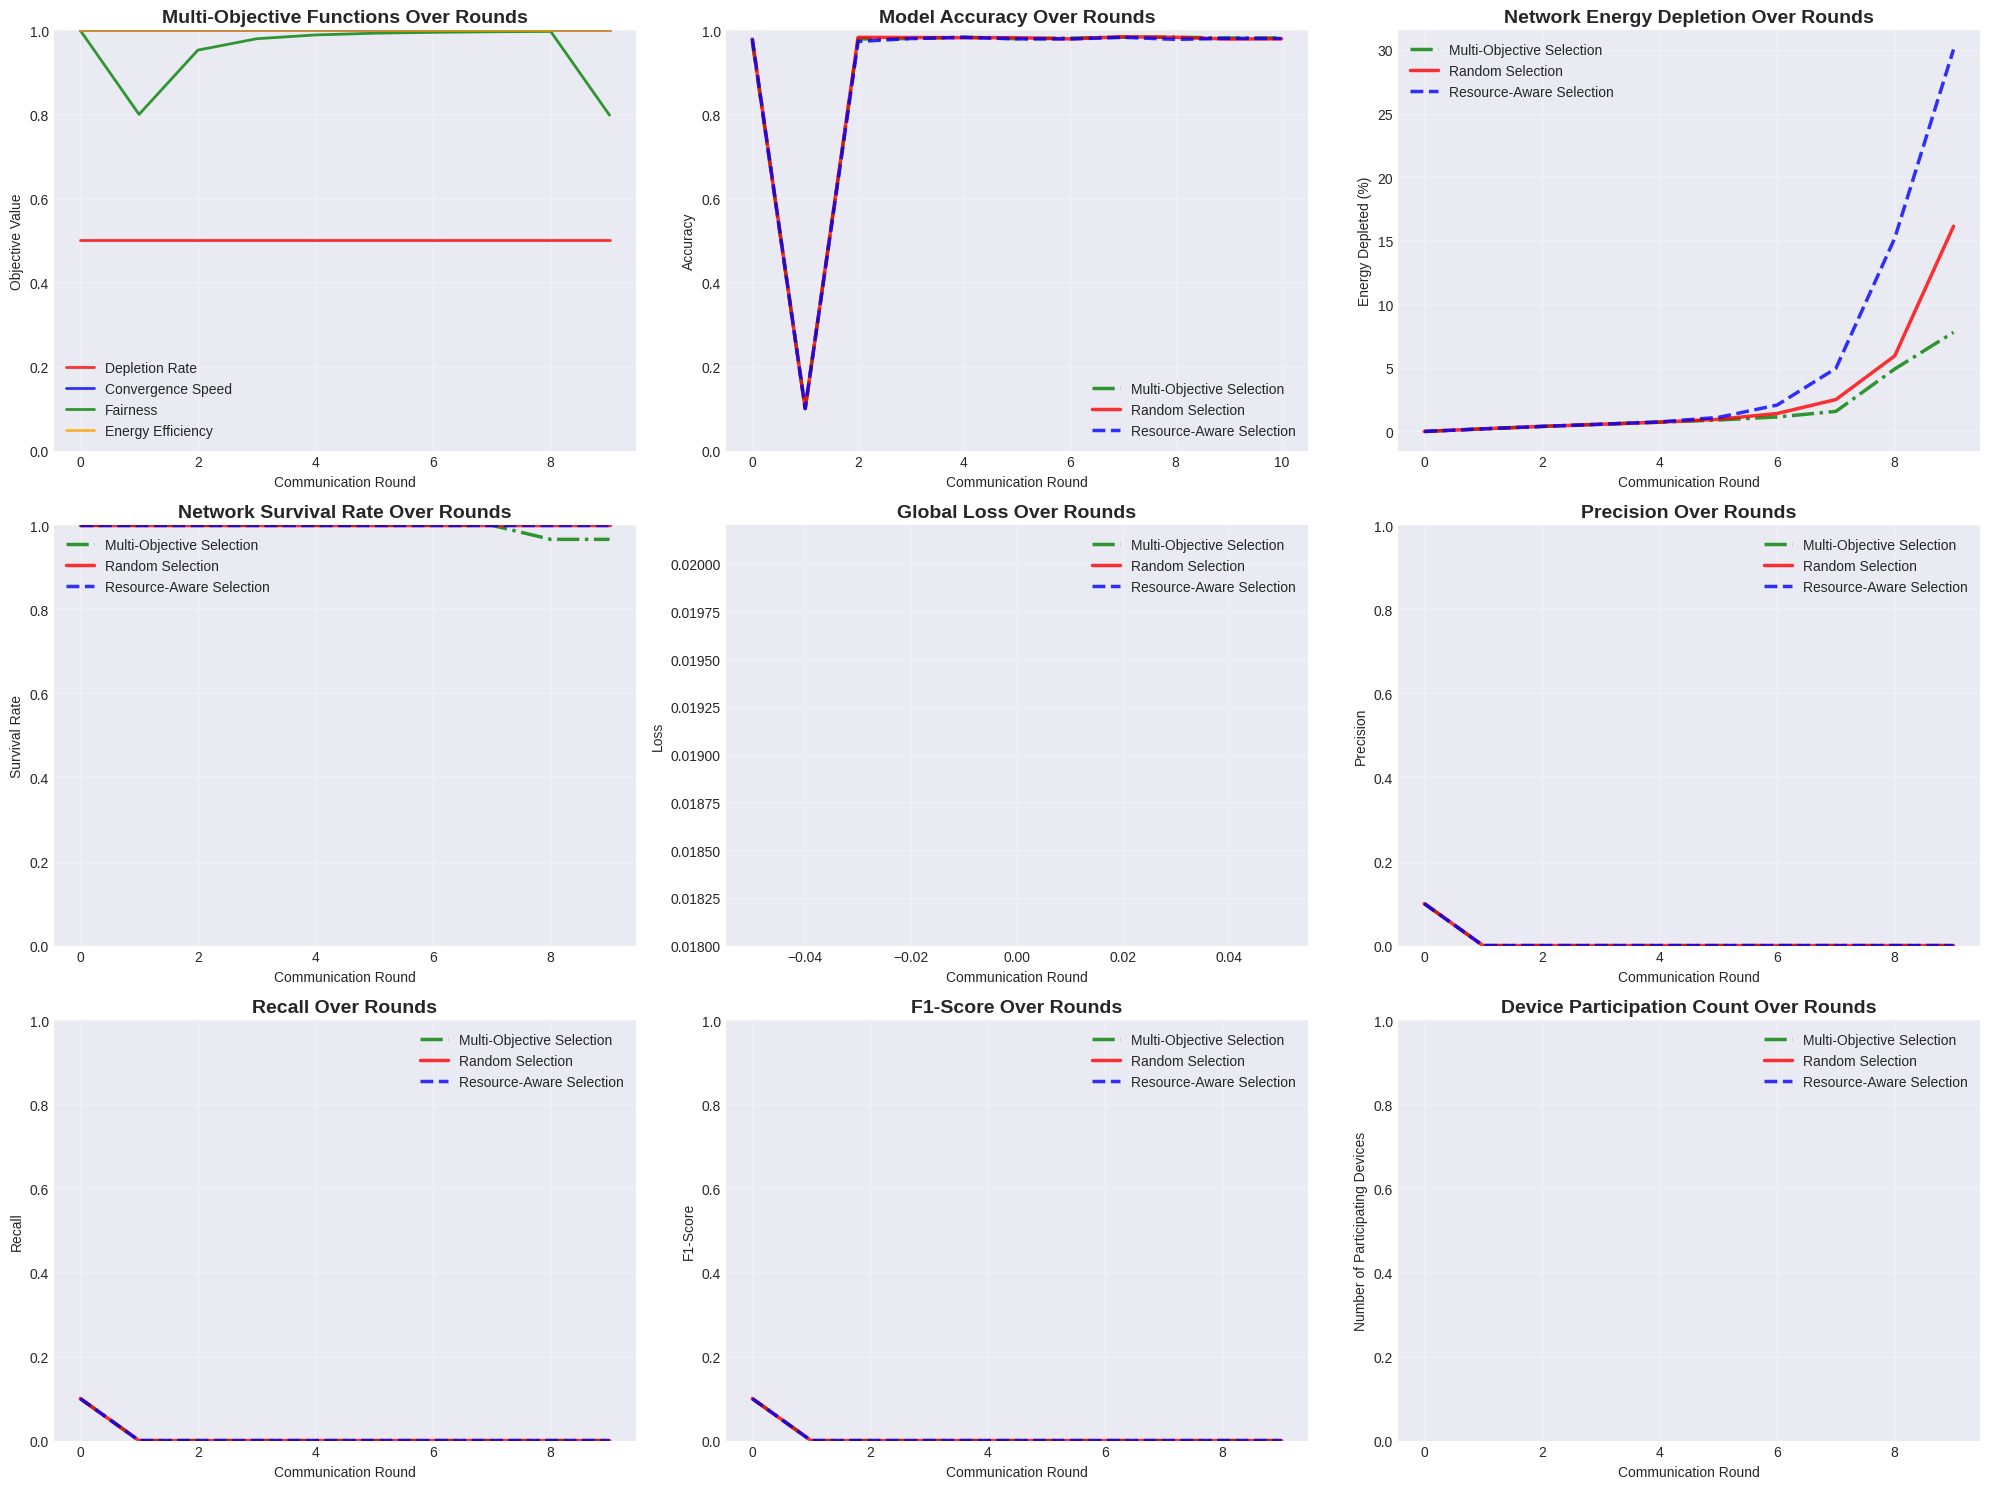

   ✓ Performance plots generated successfully

3. Generating data distribution analysis...

DATA DISTRIBUTION ACROSS CLIENTS
Total Devices: 30
Average Samples per Device: 1995.2
Average Classes per Device: 9.2

First 10 Devices - Class Proportions:
Device_ID  Total_Samples  Unique_Classes  Class_0_Prop  Class_1_Prop  Class_2_Prop  Class_3_Prop  Class_4_Prop  Class_5_Prop  Class_6_Prop  Class_7_Prop  Class_8_Prop  Class_9_Prop
 client_0           1994               9         0.054         0.253         0.009         0.001         0.144         0.000         0.421         0.013         0.035         0.071
 client_1           1996              10         0.381         0.262         0.051         0.013         0.008         0.002         0.169         0.069         0.009         0.038
 client_2           1994               8         0.165         0.004         0.036         0.000         0.003         0.050         0.099         0.000         0.624         0.020
 client_3           1996   

In [ ]:
# Usage example:
def run_complete_simulation():
    """Run the complete simulation with all scenarios"""
    # Create simulator with manageable size for testing
    simulator = FederatedLearningSimulator(
        num_devices = 30,  # Start small
        num_rounds=10,   # Shorter for testing
        selection_size=5
    )

    try:
        # Run scenarios
        print("\n1. Running simulation scenarios...")
        
        # Test each scenario individually to identify issues
        scenarios_to_test = [
            ('multi_objective', 'Multi-Objective Selection'),
            ('random', 'Random Selection'), 
            ('resource_aware', 'Resource-Aware Selection')
        ]
        
        for policy, name in scenarios_to_test:
            print(f"\n   Testing {name}...")
            try:
                simulator.initialize_simulation()  # Reset for each scenario
                results = simulator.run_scenario(policy, name)
                
                # Validate results
                if results['accuracy'] and len(results['accuracy']) > 0:
                    print(f"   ✓ {name}: Final accuracy = {results['accuracy'][-1]:.3f}")
                else:
                    print(f"   ⚠ {name}: No accuracy data recorded")
                
                if results['objective_values'] and len(results['objective_values']) > 0:
                    final_obj = results['objective_values'][-1]
                    print(f"   ✓ {name}: Final objectives recorded")
                    if final_obj.items():
                        for obj_name, value in final_obj.items():
                            print(f"      {obj_name}: {value:.3f}")
                else:
                    print(f"   ⚠ {name}: No objective data recorded")
                    
            except Exception as e:
                print(f"   ✗ {name} failed: {e}")
                import traceback
                traceback.print_exc()
        
        # Generate plots if we have any results
        print("\n2. Generating performance plots...")
        if simulator.scenario_results:
            try:
                fig = simulator.generate_performance_plots()
                print("   ✓ Performance plots generated successfully")
            except Exception as e:
                print(f"   ✗ Plot generation failed: {e}")
                import traceback
                traceback.print_exc()
        else:
            print("   ⚠ No results available for plotting")
        
        # Generate data distribution table
        print("\n3. Generating data distribution analysis...")
        try:
            df = simulator.create_data_distribution_table()
            if df is not None:
                print("   ✓ Data distribution table created")
            else:
                print("   ⚠ No data distribution available")
        except Exception as e:
            print(f"   ✗ Data distribution analysis failed: {e}")
        
        # Print summary
        print("\n6. Simulation Summary:")
        try:
            simulator.print_simulation_summary()
        except Exception as e:
            print(f"   ✗ Summary generation failed: {e}")
        
        print("\n" + "="*70)
        print("TEST COMPLETED")
        
        return simulator
        
    except Exception as e:
        print(f"\n✗ CRITICAL ERROR: {e}")
        import traceback
        traceback.print_exc()
        return None
# Run a small test simulation
print("Starting federated learning simulation test...")

# Create and run simulator
simulator = run_complete_simulation()

print("Simulation completed successfully!")